# Bangkok Airbnb EDA
## What Makes a Successful Airbnb Listing in Bangkok?

**Dataset:** Inside Airbnb Bangkok, Central Thailand (September 2025)  
**Files:** listings.csv.gz, calendar.csv.gz, reviews.csv.gz, neighbourhoods.geojson

### Guiding Questions
1. What drives listing price?
2. Which neighborhoods are most competitive?
3. What makes a high-performing host?
4. How do room type and seasonality affect price and availability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore') 
import matplotlib.ticker as ticker
from spicy import stats 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

listings = pd.read_csv('../data/listings.csv.gz', compression='gzip')
calendar = pd.read_csv('../data/calendar.csv.gz', compression='gzip')
reviews = pd.read_csv('../data/reviews.csv.gz', compression='gzip')
neighbourhoods = gpd.read_file('../data/neighbourhoods.geojson')

print(f"Listings:      {listings.shape}")
print(f"Calendar:      {calendar.shape}")
print(f"Reviews:       {reviews.shape}")
print(f"Neighbourhoods:{neighbourhoods.shape}")

Listings:      (28806, 79)
Calendar:      (10514202, 7)
Reviews:       (583333, 6)
Neighbourhoods:(50, 3)


In [2]:
COLORS = {
    'primary':    '#2563EB',  # blue — main distributions
    'secondary':  '#F59E0B',  # amber — highlights/annotations
    'accent':     '#10B981',  # green — positive insights
    'neutral':    '#6B7280',  # gray — secondary elements
    'background': '#F8FAFC'   # light gray — figure background
}

FONT = {'family': 'DejaVu Sans', 'size': 11}
plt.rcParams.update({
    'font.family':       FONT['family'],
    'font.size':         FONT['size'],
    'axes.spines.top':   False,  
    'axes.spines.right': False,  
    'figure.facecolor':  COLORS['background'],
    'axes.facecolor':    COLORS['background'],
})

## Section 1 — Data Overview

Before any analysis, we need to understand what we're working with:
- How many rows and columns?
- What are the data types?
- Which columns have missing values?
- What does the data actually look like?

In [3]:
print(f"Shape: {listings.shape}")
print(f"\nColumn names:\n {listings.columns.tolist()}")

Shape: (28806, 79)

Column names:
 ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability

In [4]:
col_groups = {
    'identifiers':    ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url'],
    'listing_info':   ['name', 'description', 'neighborhood_overview', 'property_type', 'room_type',
                       'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities'],
    'host_info':      ['host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
                       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
                       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
                       'host_neighbourhood', 'host_listings_count', 'host_total_listings_count',
                       'host_verifications', 'host_has_profile_pic', 'host_identity_verified'],
    'location':       ['neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
                       'latitude', 'longitude'],
    'pricing':        ['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
                       'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
                       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'],
    'availability':   ['has_availability', 'availability_30', 'availability_60', 'availability_90',
                       'availability_365', 'availability_eoy', 'calendar_updated', 'calendar_last_scraped'],
    'reviews':        ['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
                       'number_of_reviews_ly', 'first_review', 'last_review', 'review_scores_rating',
                       'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                       'review_scores_communication', 'review_scores_location', 'review_scores_value',
                       'reviews_per_month'],
    'business':       ['license', 'instant_bookable', 'calculated_host_listings_count',
                       'calculated_host_listings_count_entire_homes',
                       'calculated_host_listings_count_private_rooms',
                       'calculated_host_listings_count_shared_rooms',
                       'estimated_occupancy_l365d', 'estimated_revenue_l365d']
}

for group, cols in col_groups.items():
    print(f"{group.upper():20} ({len(cols)} cols): {cols[:4]}{'...' if len(cols) > 4 else ''}")

IDENTIFIERS          (6 cols): ['id', 'listing_url', 'scrape_id', 'last_scraped']...
LISTING_INFO         (11 cols): ['name', 'description', 'neighborhood_overview', 'property_type']...
HOST_INFO            (18 cols): ['host_id', 'host_url', 'host_name', 'host_since']...
LOCATION             (5 cols): ['neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude']...
PRICING              (9 cols): ['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights']...
AVAILABILITY         (8 cols): ['has_availability', 'availability_30', 'availability_60', 'availability_90']...
REVIEWS              (14 cols): ['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly']...
BUSINESS             (8 cols): ['license', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes']...


In [5]:
print("DATA TYPES")
print(listings.dtypes.value_counts())
print(f"\nTotal columns: {listings.shape[1]}")

DATA TYPES
str        34
float64    25
int64      20
Name: count, dtype: int64

Total columns: 79


In [6]:
missing=listings.isnull().sum()
missing_pct=(missing / len(listings) * 100).round(1)
missing_df=pd.DataFrame({'missing_count': missing, 
                         'missing_pct': missing_pct
                         }).query('missing_count>0').sort_values('missing_pct', ascending=False)
print(f"Columns WITH missing values: {len(missing_df)} out of {listings.shape[1]}")
print(f"Columns with NO missing values: {listings.shape[1] - len(missing_df)}\n")
print(missing_df.to_string())


Columns WITH missing values: 43 out of 79
Columns with NO missing values: 36

                              missing_count  missing_pct
license                               28806        100.0
calendar_updated                      28806        100.0
neighbourhood_group_cleansed          28806        100.0
host_neighbourhood                    19436         67.5
neighborhood_overview                 19322         67.1
neighbourhood                         19322         67.1
host_about                            11990         41.6
review_scores_cleanliness             10091         35.0
reviews_per_month                     10090         35.0
review_scores_value                   10096         35.0
first_review                          10090         35.0
review_scores_rating                  10090         35.0
review_scores_accuracy                10090         35.0
review_scores_checkin                 10093         35.0
review_scores_communication           10091         35.0
review_sco

In [7]:
cols_to_drop = [
    'license',                      # 100% missing
    'calendar_updated',             # 100% missing
    'neighbourhood_group_cleansed', # 100% missing
    'neighbourhood',                # 67% missing — neighbourhood_cleansed is better
    'listing_url',                  # not needed for analysis
    'scrape_id',                    # metadata
    'picture_url',                  # metadata
    'host_url',                     # metadata
    'host_thumbnail_url',           # metadata
    'host_picture_url',             # metadata
]

listings = listings.drop(columns=cols_to_drop)
print(f"Columns after dropping: {listings.shape[1]}")
print(f"Dropped: {len(cols_to_drop)} columns")

Columns after dropping: 69
Dropped: 10 columns


In [8]:
print(listings['price'].dtype)
print(listings['price'].head(10))

str
0    $1,595.00
1          NaN
2          NaN
3    $4,188.00
4    $1,450.00
5    $1,368.00
6          NaN
7    $5,600.00
8    $1,147.00
9    $1,416.00
Name: price, dtype: str


In [9]:
listings['price'] = (listings['price']
                     .str.replace('$', '', regex=False)
                     .str.replace(',', '', regex=False)
                     .astype(float))

print(f"dtype after cleaning: {listings['price'].dtype}")
print(f"Missing prices: {listings['price'].isnull().sum()}")
print(f"\nPrice statistics:")
print(listings['price'].describe().round(2))

dtype after cleaning: float64
Missing prices: 5533

Price statistics:
count      23273.00
mean        2528.75
std        16473.90
min            4.00
25%          923.00
50%         1379.00
75%         2207.00
max      1000000.00
Name: price, dtype: float64


In [10]:
# Investigate outliers
print("Listings with price > 50,000 THB:")
print(listings[listings['price'] > 50000][['name', 'price', 'room_type', 'accommodates']].sort_values('price', ascending=False).head(10))

print(f"\nListings with price < 100 THB:")
print(listings[listings['price'] < 100][['name', 'price', 'room_type', 'accommodates']].head(10))

Listings with price > 50,000 THB:
                                                    name      price  \
979                   Modern,wifi,5m MRT&2 Shopping Mall  1000000.0   
1442                  2 Bedroom,wifi,5mMRT&Shopping Mall  1000000.0   
1946   Resort Style Luxury apartment,5min to MRT,free...  1000000.0   
3723        Modern&Luxury apartment,5min to MRT,freeWifi  1000000.0   
3276                       Ideo verse ratchaprarop condo   928572.0   
4676                                     Gemma Sukhumvit   860000.0   
15326  Loft Green Bangkok Couple or Friends Room (Max 3)   433108.0   
26664                        A comfy Home in Central BKK   321829.0   
12719                       Siri Sala Private Thai Villa   184368.0   
5162   【ExLN:9min to BTS/MRT&Terminal21,Big Balcony,Q...   153014.0   

             room_type  accommodates  
979    Entire home/apt             4  
1442   Entire home/apt             5  
1946   Entire home/apt             7  
3723   Entire home/apt      

In [11]:
price_lower = 100
price_upper = 50000

listings_clean = listings[
    (listings['price'] >= price_lower) &
    (listings['price'] <= price_upper)
].copy()  

print(f"Listings before outlier removal: {len(listings)}")
print(f"Listings after outlier removal:  {len(listings_clean)}")
print(f"Removed: {len(listings) - len(listings_clean)} listings ({((len(listings) - len(listings_clean)) / len(listings) * 100):.1f}%)")
print(f"\nPrice range after cleaning: {listings_clean['price'].min()} — {listings_clean['price'].max()} THB")
print(f"New mean:   {listings_clean['price'].mean():.0f} THB")
print(f"New median: {listings_clean['price'].median():.0f} THB")

Listings before outlier removal: 28806
Listings after outlier removal:  23233
Removed: 5573 listings (19.3%)

Price range after cleaning: 122.0 — 50000.0 THB
New mean:   2141 THB
New median: 1378 THB


### Data Cleaning Decisions

| Column | Issue | Action | Reason |
|--------|-------|--------|--------|
| `license`, `calendar_updated`, `neighbourhood_group_cleansed` | 100% missing | Dropped | No analytical value |
| `neighbourhood` | 67% missing | Dropped | `neighbourhood_cleansed` is the clean version |
| 8 URL/metadata columns | Not needed for analysis | Dropped | Reduce noise |
| `price` | Stored as string with `$` and `,` | Converted to float | Required for any numeric analysis |
| `price` < 100 THB | Likely test/error listings | Removed | Not realistic rental prices |
| `price` > 50,000 THB | Data entry errors or placeholders | Removed | Distort distributions and averages |

**Working dataset: 23,233 listings × 69 columns**  
**Price range: 122 — 50,000 THB**  
**Note:** ~35% of listings have no review scores, these are new listings not bad data. They are kept in the dataset but excluded from review-based analysis.

## Section 2 — Price Analysis
**Question: What drives listing price in Bangkok?**

We'll analyze:
- How prices are distributed
- Which features correlate most with price
- What the key price drivers are

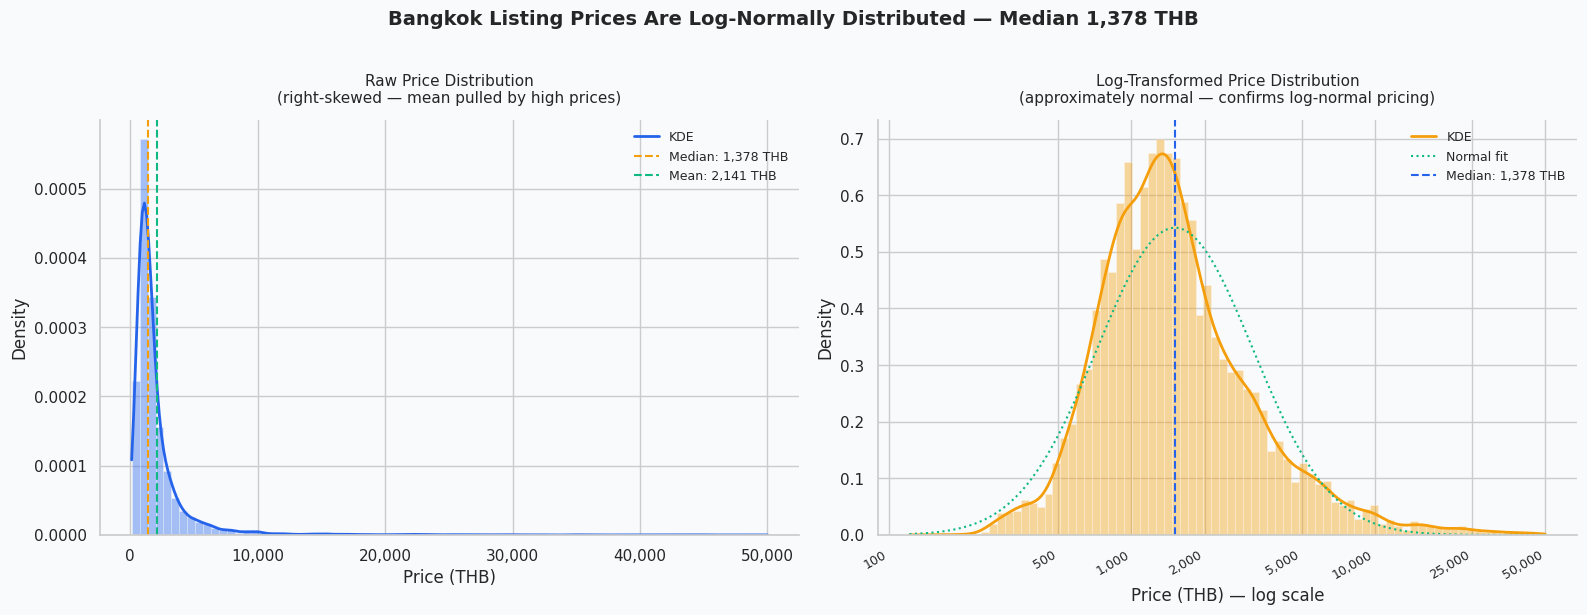

Skewness (raw):           6.86  (>1 = heavily right-skewed)
Skewness (log-transform): 0.86  (near 0 = approximately normal)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bangkok Listing Prices Are Log-Normally Distributed — Median 1,378 THB',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
price_data = listings_clean['price'].dropna()

ax.hist(price_data, bins=80, density=True,
        color=COLORS['primary'], alpha=0.4, edgecolor='white', linewidth=0.5)

kde_x = np.linspace(price_data.min(), price_data.max(), 300)
kde = stats.gaussian_kde(price_data)
ax.plot(kde_x, kde(kde_x), color=COLORS['primary'], linewidth=2, label='KDE')

median_price = price_data.median()
mean_price = price_data.mean()
ax.axvline(median_price, color=COLORS['secondary'], linewidth=1.5,
           linestyle='--', label=f'Median: {median_price:,.0f} THB')
ax.axvline(mean_price, color=COLORS['accent'], linewidth=1.5,
           linestyle='--', label=f'Mean: {mean_price:,.0f} THB')

ax.set_title('Raw Price Distribution\n(right-skewed — mean pulled by high prices)',
             fontsize=11, pad=12)
ax.set_xlabel('Price (THB)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(frameon=False, fontsize=9)

ax = axes[1]

log_price = np.log1p(price_data)

ax.hist(log_price, bins=80, density=True,
        color=COLORS['secondary'], alpha=0.4, edgecolor='white', linewidth=0.5)

kde_x_log = np.linspace(log_price.min(), log_price.max(), 300)
kde_log = stats.gaussian_kde(log_price)
ax.plot(kde_x_log, kde_log(kde_x_log), color=COLORS['secondary'], linewidth=2, label='KDE')

mu, std = log_price.mean(), log_price.std()
normal_curve = stats.norm.pdf(kde_x_log, mu, std)
ax.plot(kde_x_log, normal_curve, color=COLORS['accent'], linewidth=1.5,
        linestyle=':', label='Normal fit')

ax.axvline(mu, color=COLORS['primary'], linewidth=1.5,
           linestyle='--', label=f'Median: {median_price:,.0f} THB')

# Convert log tick positions back to real THB values for human readability
tick_positions = np.log1p([100, 500, 1000, 2000, 5000, 10000, 25000, 50000])
tick_labels = ['100', '500', '1,000', '2,000', '5,000', '10,000', '25,000', '50,000']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=9)

ax.set_title('Log-Transformed Price Distribution\n(approximately normal — confirms log-normal pricing)',
             fontsize=11, pad=12)
ax.set_xlabel('Price (THB) — log scale')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"Skewness (raw):           {price_data.skew():.2f}  (>1 = heavily right-skewed)")
print(f"Skewness (log-transform): {log_price.skew():.2f}  (near 0 = approximately normal)")

### Finding 1 — Price Distribution

Bangkok’s rental market is heavily right-skewed ($skew = 6.86$). While the "typical" stay costs ~1,400 THB (median), a small cluster of luxury listings pulls the mean significantly higher (2,141 THB).

Log-transformation reduces skewness to 0.86  
Confirmed prices follow a log-normal distribution, which is standard for marketplace pricing data.

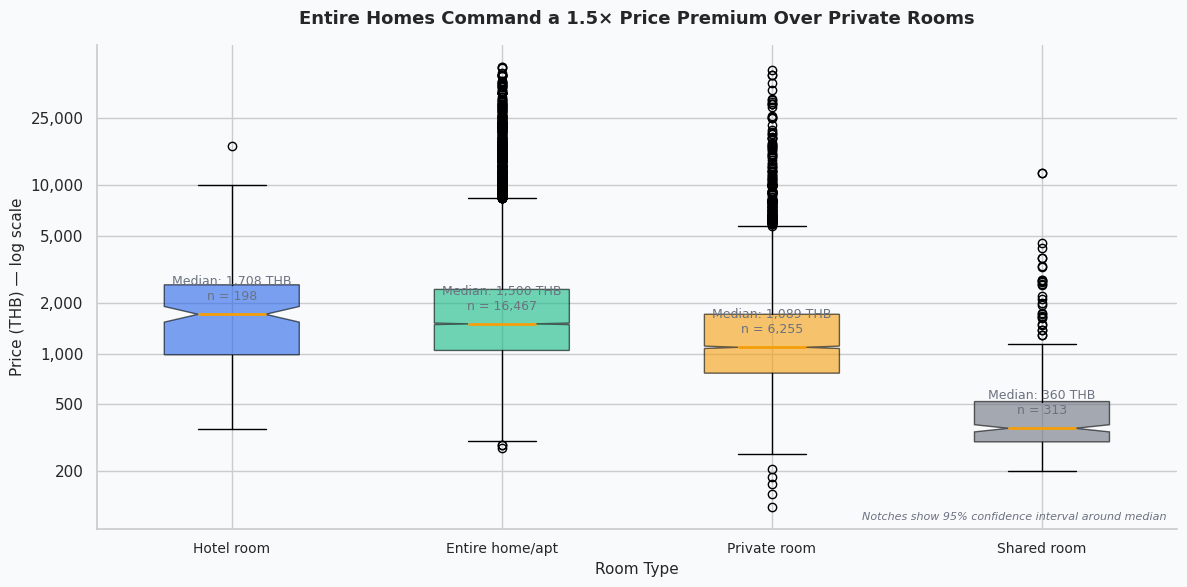

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate median and count per room type for annotations
room_stats = (listings_clean
              .groupby('room_type')['price']
              .agg(['median', 'count'])
              .sort_values('median', ascending=False))

room_order = room_stats.index.tolist()

# Boxplot on log-transformed price
data_by_room = [np.log1p(listings_clean[listings_clean['room_type'] == r]['price'].dropna())
                for r in room_order]

bp = ax.boxplot(data_by_room,
                patch_artist=True,    
                notch=True,           
                vert=True,
                widths=0.5,
                medianprops=dict(color=COLORS['secondary'], linewidth=2))

box_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary'], COLORS['neutral']]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Convert y-axis ticks back to real THB values
tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

for i, room in enumerate(room_order):
    median = room_stats.loc[room, 'median']
    count  = room_stats.loc[room, 'count']
    ax.text(i + 1, np.log1p(median) + 0.15,
            f'Median: {median:,.0f} THB\nn = {count:,}',
            ha='center', va='bottom', fontsize=9,
            color=COLORS['neutral'])

ax.set_xticklabels(room_order, fontsize=10)
ax.set_title('Entire Homes Command a 1.5× Price Premium Over Private Rooms',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Room Type', fontsize=11)
ax.set_ylabel('Price (THB) — log scale', fontsize=11)

ax.annotate('Notches show 95% confidence interval around median',
            xy=(0.99, 0.02), xycoords='axes fraction',
            ha='right', fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.show()

### Finding 2 — Price by Room Type

Entire homes dominate the market (70% of listings) and price 1.5× higher than 
private rooms (1,500 vs 989 THB/night). Private rooms show the widest price 
variance.  
Shared rooms (360 THB) and hotel rooms (198 listings) are negligible segments.

*Room type will be treated as a confounding variable in subsequent analysis.*

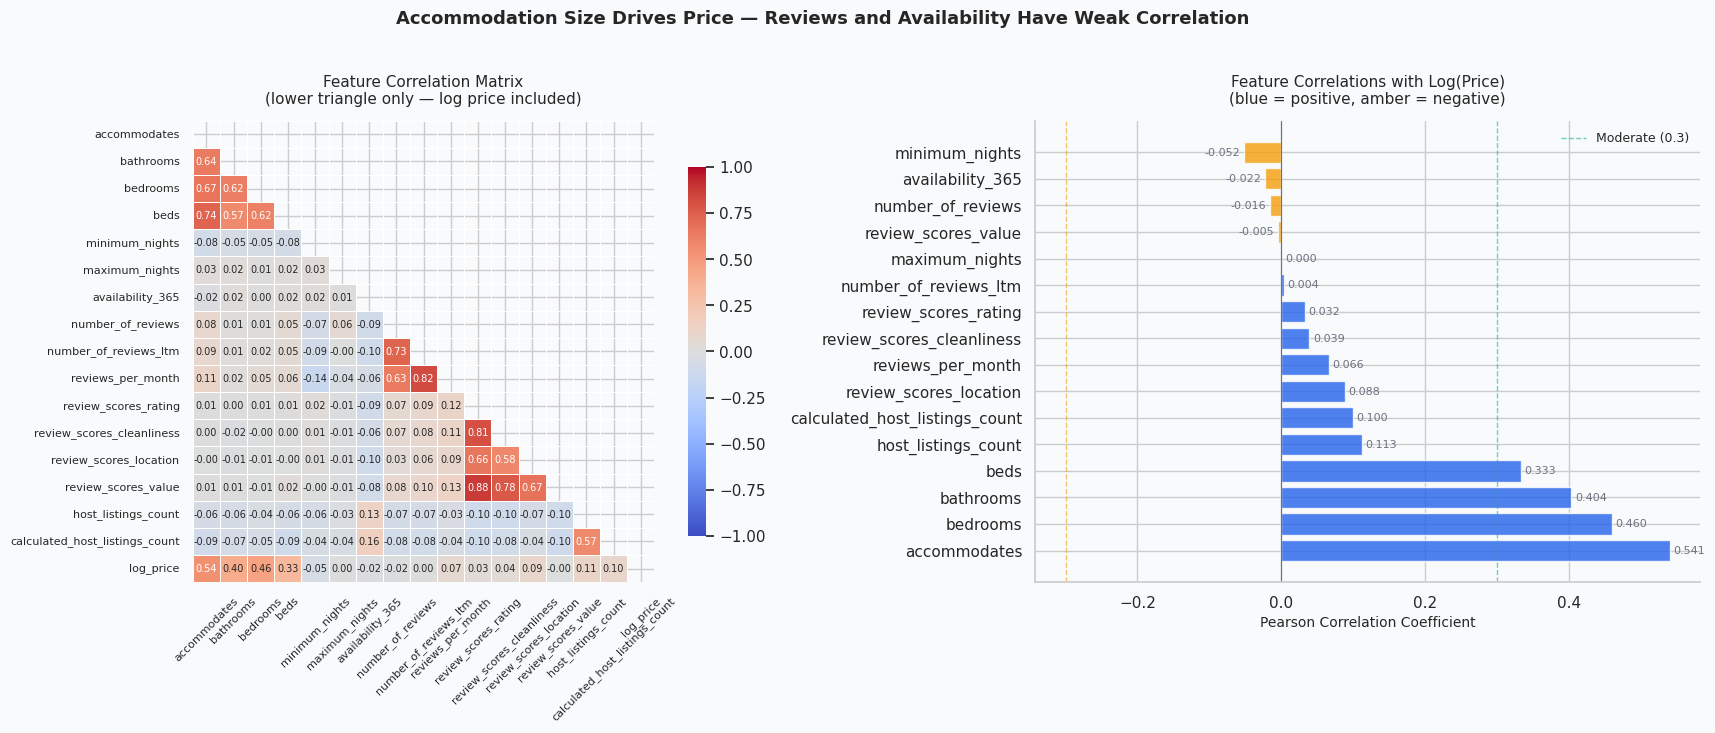

Top positive correlators with price:
accommodates           0.540979
bedrooms               0.459981
bathrooms              0.403838
beds                   0.333355
host_listings_count    0.112593

Top negative correlators with price:
Series([], )


In [14]:
numeric_cols = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_listings_count', 'calculated_host_listings_count'
]

corr_df = listings_clean[numeric_cols].copy()

corr_df['log_price'] = np.log1p(corr_df['price'])
corr_df = corr_df.drop(columns=['price'])

corr_matrix = corr_df.corr()

# Extract only correlations with log_price, sorted
price_corr = (corr_matrix['log_price']
              .drop('log_price')
              .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 7},
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix\n(lower triangle only — log price included)',
             fontsize=11, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

ax = axes[1]

colors = [COLORS['primary'] if v > 0 else COLORS['secondary'] for v in price_corr.values]
bars = ax.barh(price_corr.index, price_corr.values, color=colors, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, price_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8,
            color=COLORS['neutral'])

ax.axvline(0, color=COLORS['neutral'], linewidth=0.8, linestyle='-')

ax.axvline(0.3,  color=COLORS['accent'],    linewidth=1, linestyle='--', alpha=0.6, label='Moderate (0.3)')
ax.axvline(-0.3, color=COLORS['secondary'], linewidth=1, linestyle='--', alpha=0.6)

ax.set_title('Feature Correlations with Log(Price)\n(blue = positive, amber = negative)',
             fontsize=11, pad=12)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=10)
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Accommodation Size Drives Price — Reviews and Availability Have Weak Correlation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Top positive correlators with price:")
print(price_corr[price_corr > 0.1].to_string())
print("\nTop negative correlators with price:")
print(price_corr[price_corr < -0.1].to_string())

### Finding 3 — Price Drivers (Correlation Analysis)

Accommodation size dominates price: accommodates (r=0.54), bedrooms (r=0.46), 
bathrooms (r=0.40), and beds (r=0.33) are the only meaningful predictors. 
All other features (review scores, availability, minimum nights)  show 
near-zero correlation (|r| < 0.12).

These four size features are highly correlated with each other (multicollinearity) 
they all measure the same thing: property size. For any future model, 
use `accommodates` only (strongest r).

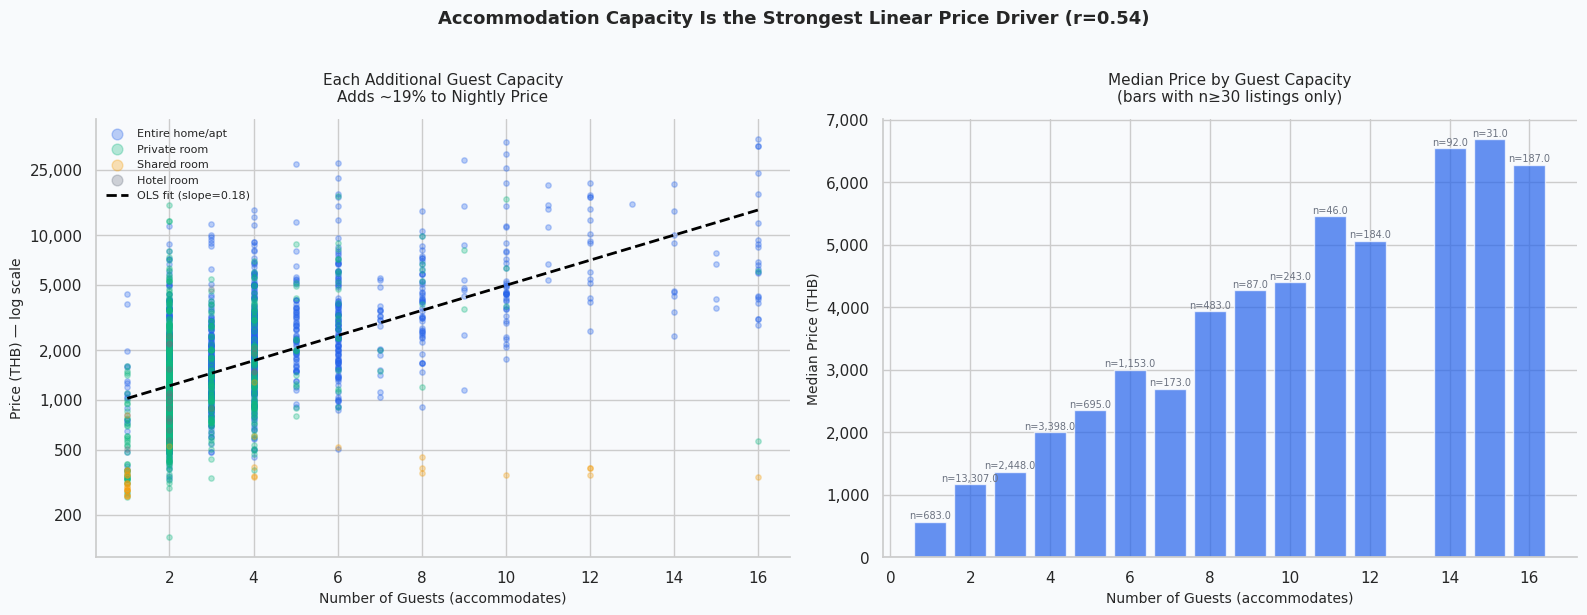

OLS slope: 0.176 in log scale
Interpretation: each additional guest capacity increases price by ~19.2%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]

# Sample 3000 points — plotting all 23k points creates overplotting
sample = listings_clean[['accommodates', 'price', 'room_type']].dropna().sample(3000, random_state=42)
log_sample_price = np.log1p(sample['price'])

room_types = sample['room_type'].unique()
room_colors = {
    'Entire home/apt': COLORS['primary'],
    'Private room':    COLORS['accent'],
    'Shared room':     COLORS['secondary'],
    'Hotel room':      COLORS['neutral']
}

for room in room_types:
    mask = sample['room_type'] == room
    ax.scatter(sample.loc[mask, 'accommodates'],
               log_sample_price[mask],
               color=room_colors.get(room, COLORS['neutral']),
               alpha=0.3, s=15, label=room)

m, b = np.polyfit(sample['accommodates'], log_sample_price, 1)
x_line = np.linspace(sample['accommodates'].min(), sample['accommodates'].max(), 100)
ax.plot(x_line, m * x_line + b,
        color='black', linewidth=2, linestyle='--', label=f'OLS fit (slope={m:.2f})')

tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

ax.set_title('Each Additional Guest Capacity\nAdds ~19% to Nightly Price',
             fontsize=11, pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Price (THB) — log scale', fontsize=10)
ax.legend(frameon=False, fontsize=8, markerscale=2)

ax = axes[1]

median_by_acc = (listings_clean
                 .groupby('accommodates')['price']
                 .agg(['median', 'count'])
                 .reset_index()
                 .query('count >= 30'))  # only show groups with enough data

ax.bar(median_by_acc['accommodates'], median_by_acc['median'],
       color=COLORS['primary'], alpha=0.7, edgecolor='white')

for _, row in median_by_acc.iterrows():
    ax.text(row['accommodates'], row['median'] + 50,
            f"n={row['count']:,}",
            ha='center', fontsize=7, color=COLORS['neutral'])

ax.set_title('Median Price by Guest Capacity\n(bars with n≥30 listings only)',
             fontsize=11, pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Median Price (THB)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Accommodation Capacity Is the Strongest Linear Price Driver (r=0.54)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

slope_pct = (np.exp(m) - 1) * 100
print(f"OLS slope: {m:.3f} in log scale")
print(f"Interpretation: each additional guest capacity increases price by ~{slope_pct:.1f}%")

### Finding 4 — Accommodation Capacity vs Price

Each additional guest capacity increases nightly price by approximately 19%, 
confirming accommodates as the strongest linear price driver (r=0.54). 
A listing for 4 guests has a median price of ~1,500 THB vs ~800 THB for 
a solo listing.

The relationship holds consistently up to 10 guests but becomes unreliable 
beyond that due to thin sample sizes. Private rooms maintain a price ceiling 
regardless of capacity, suggesting room type acts as an upper bound on what 
the market will pay.

## Section 3 — Neighborhood Analysis
**Question: Which neighborhoods are most competitive in Bangkok?**

We'll analyze:
- Which neighborhoods have the most listings (supply)?
- Which neighborhoods command the highest prices?
- Is there a tradeoff between price and volume?
- Geographic distribution of prices across the city

In [16]:
# Neighborhood overview
neighbourhood_stats = (listings_clean
    .groupby('neighbourhood_cleansed')
    .agg(
        listing_count  = ('id', 'count'),
        median_price   = ('price', 'median'),
        mean_price     = ('price', 'mean'),
        avg_rating     = ('review_scores_rating', 'mean'),
        avg_avail_365  = ('availability_365', 'mean')
    )
    .round(1)
    .sort_values('listing_count', ascending=False)
    .reset_index()
)

print(f"Total neighbourhoods: {len(neighbourhood_stats)}")
print(f"\nTop 10 by listing count:")
print(neighbourhood_stats.head(10).to_string(index=False))

Total neighbourhoods: 50

Top 10 by listing count:
neighbourhood_cleansed  listing_count  median_price  mean_price  avg_rating  avg_avail_365
               Vadhana           3700        1823.5      3235.4         4.7          257.2
           Khlong Toei           3117        1622.0      2410.6         4.7          270.8
           Huai Khwang           3023        1400.0      1725.4         4.6          291.8
           Ratchathewi           1241        1586.0      2098.5         4.7          260.2
                Sathon           1090        1163.0      1941.0         4.7          276.5
          Phra Khanong           1001        1184.0      1591.3         4.7          279.0
           Phra Nakhon            923        1101.0      1564.5         4.7          311.8
              Bang Rak            755        1890.0      2753.8         4.8          260.3
             Suanluang            728        1045.0      1779.9         4.6          303.0
            Chatu Chak            681  

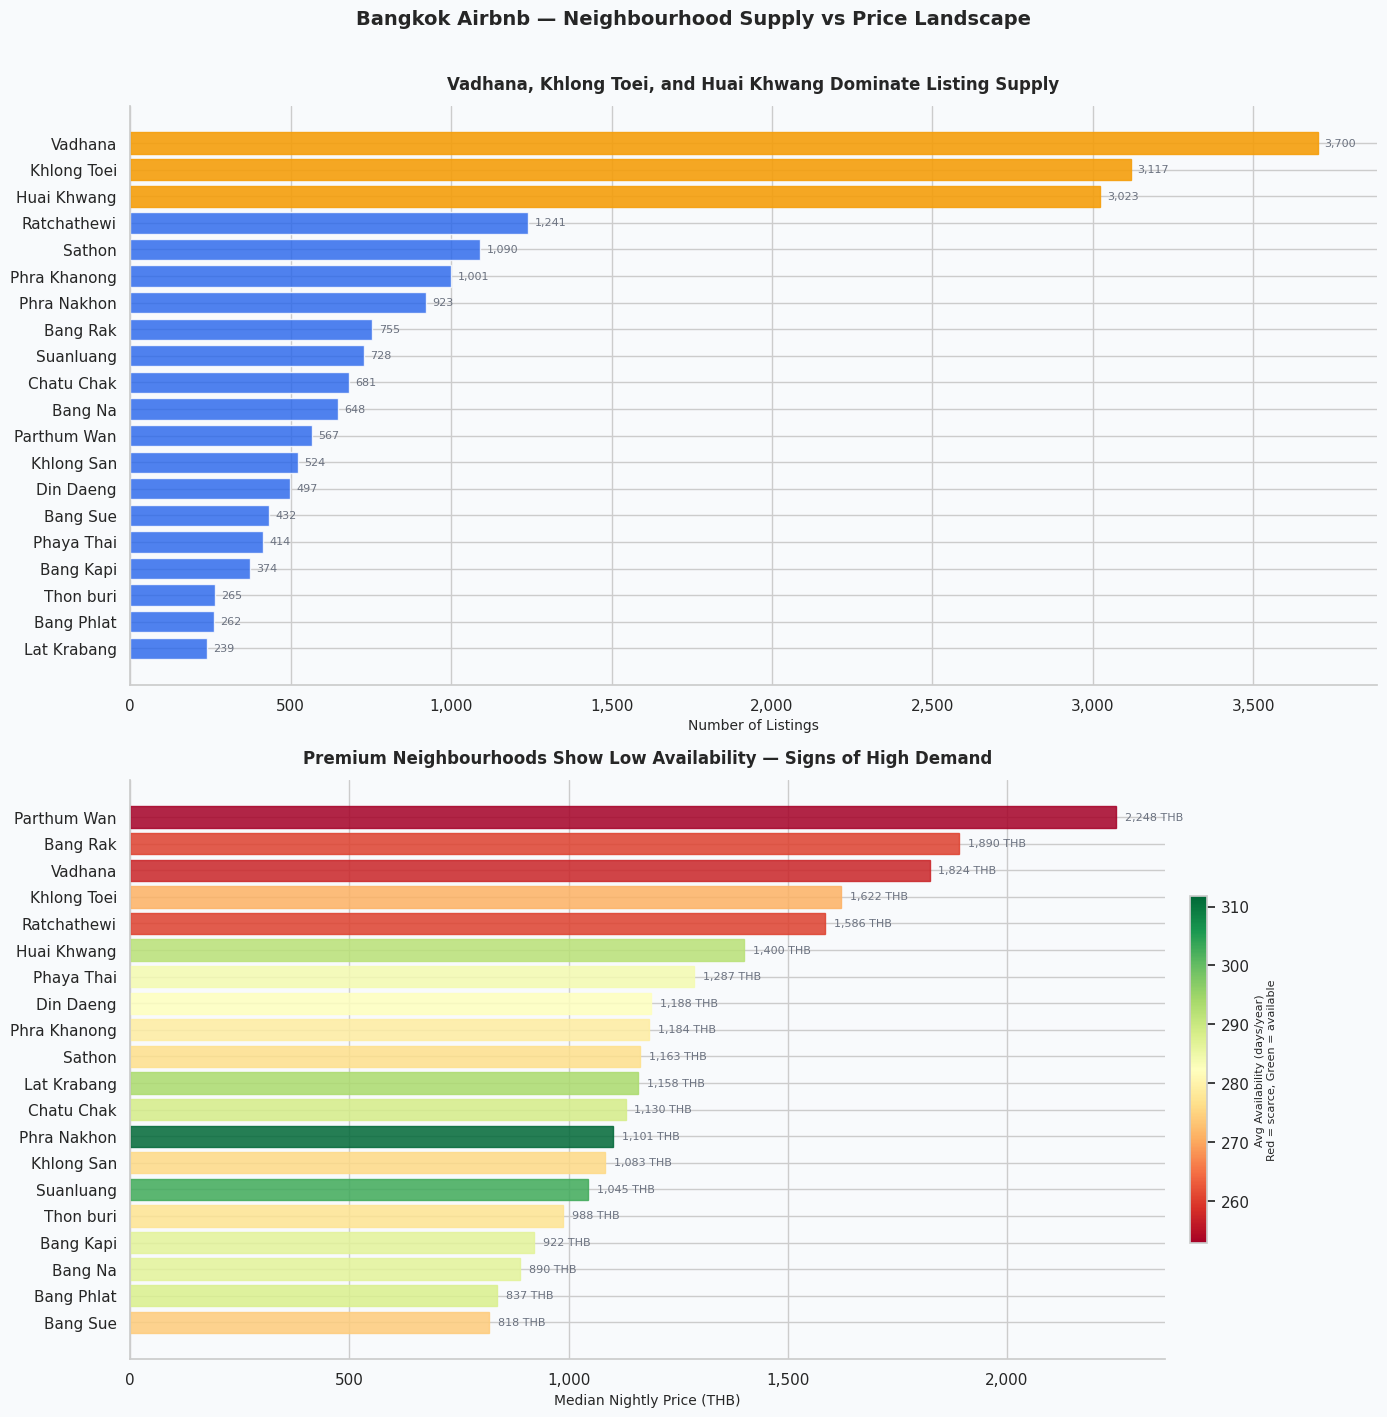

Correlation between median price and availability: -0.478

Most expensive neighbourhoods (top 5 by median price):
neighbourhood_cleansed  median_price  avg_avail_365
           Parthum Wan        2248.0          252.8
              Bang Rak        1890.0          260.3
        Samphanthawong        1879.0          290.3
               Vadhana        1823.5          257.2
           Khlong Toei        1622.0          270.8

Most affordable neighbourhoods (bottom 5 by median price):
neighbourhood_cleansed  median_price  avg_avail_365
            Nong Khaem         581.0          271.2
             Nong Chok         708.5          321.2
         Khlong Sam Wa         763.5          341.8
              Bang Bon         784.0          293.7
                Lak Si         800.0          306.2


In [17]:
# Use top 20 neighbourhoods for readability
top20 = neighbourhood_stats.head(20).copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

ax = axes[0]

bars = ax.barh(top20['neighbourhood_cleansed'][::-1],
               top20['listing_count'][::-1],
               color=COLORS['primary'], alpha=0.8, edgecolor='white')

for i, bar in enumerate(bars):
    if i >= len(bars) - 3:
        bar.set_color(COLORS['secondary'])
        bar.set_alpha(0.9)

for bar, val in zip(bars, top20['listing_count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Vadhana, Khlong Toei, and Huai Khwang Dominate Listing Supply',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Listings', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax = axes[1]

top20_by_price = top20.sort_values('median_price', ascending=True)

bars = ax.barh(top20_by_price['neighbourhood_cleansed'],
               top20_by_price['median_price'],
               color=COLORS['primary'], alpha=0.7, edgecolor='white')

norm = plt.Normalize(top20_by_price['avg_avail_365'].min(),
                     top20_by_price['avg_avail_365'].max())
cmap = plt.cm.RdYlGn  

for bar, avail in zip(bars, top20_by_price['avg_avail_365']):
    bar.set_color(cmap(norm(avail)))
    bar.set_alpha(0.85)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Avg Availability (days/year)\nRed = scarce, Green = available', fontsize=8)

for bar, val in zip(bars, top20_by_price['median_price']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f} THB', va='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Premium Neighbourhoods Show Low Availability — Signs of High Demand',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Median Nightly Price (THB)', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Bangkok Airbnb — Neighbourhood Supply vs Price Landscape',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

corr = neighbourhood_stats['median_price'].corr(neighbourhood_stats['avg_avail_365'])
print(f"Correlation between median price and availability: {corr:.3f}")
print(f"\nMost expensive neighbourhoods (top 5 by median price):")
print(neighbourhood_stats.nlargest(5, 'median_price')[['neighbourhood_cleansed', 'median_price', 'avg_avail_365']].to_string(index=False))
print(f"\nMost affordable neighbourhoods (bottom 5 by median price):")
print(neighbourhood_stats.nsmallest(5, 'median_price')[['neighbourhood_cleansed', 'median_price', 'avg_avail_365']].to_string(index=False))

### Finding 5 — Neighbourhood Supply vs Price

Central districts (Parthum Wan, Bang Rak, Vadhana) price 3–4× higher than 
peripheral areas (580–710 THB). Expensive neighbourhoods also show lower 
availability (r=-0.478) they get booked faster, confirming real demand.

The key insight: high listing volume ≠ high price. Vadhana and Huai Khwang 
lead in supply but don't lead in price. Parthum Wan commands the highest 
prices with far fewer listings. Scarcity and location matter more than volume.

In [18]:
# Merge neighbourhood stats with geojson for mapping
geo_df = neighbourhoods.merge(
    neighbourhood_stats[['neighbourhood_cleansed', 'median_price', 
                          'listing_count', 'avg_avail_365']],
    left_on='neighbourhood',   
    right_on='neighbourhood_cleansed',
    how='left'
)

print(f"Geo dataframe shape: {geo_df.shape}")
print(f"Missing after merge: {geo_df['median_price'].isnull().sum()}")
print(geo_df[['neighbourhood', 'median_price', 'listing_count']].head())

Geo dataframe shape: (50, 7)
Missing after merge: 0
     neighbourhood  median_price  listing_count
0       Bang Phlat         837.0            262
1      Huai Khwang        1400.0           3023
2  Wang Thong Lang         958.0            142
3   Thawi Watthana        1060.0             21
4      Lat Krabang        1158.0            239


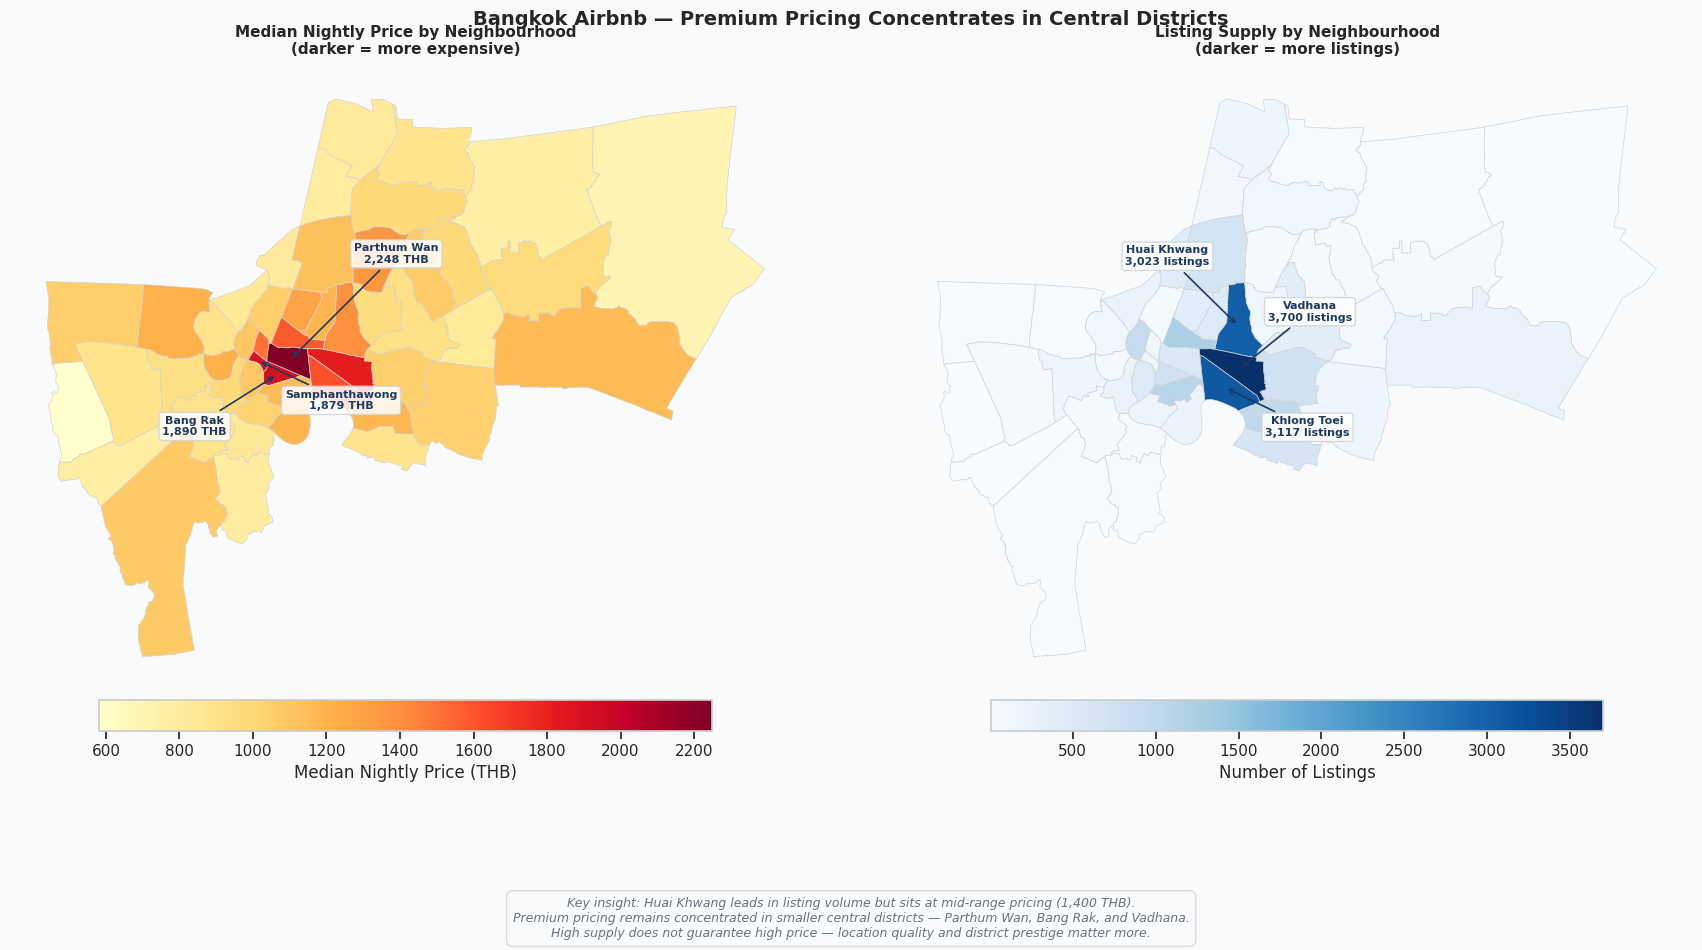

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ax = axes[0]

geo_df.plot(
    column='median_price',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='lightgray',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Median Nightly Price (THB)',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    }
)

top3_price = neighbourhood_stats.nlargest(3, 'median_price')
# Manual offsets to avoid overlap — tuned for Bangkok's geography
label_offsets = {
    'Parthum Wan':     (0.09,  0.08),
    'Bang Rak':        (-0.07, -0.05),
    'Samphanthawong':  (0.07, -0.04),
}

for _, row in top3_price.iterrows():
    name = row['neighbourhood_cleansed']
    centroid = geo_df[geo_df['neighbourhood_cleansed'] == name].geometry.centroid
    if not centroid.empty:
        cx, cy = centroid.x.values[0], centroid.y.values[0]
        dx, dy = label_offsets.get(name, (0.05, 0.05))
        ax.annotate(
            f"{name}\n{row['median_price']:,.0f} THB",
            xy=(cx, cy),
            xytext=(cx + dx, cy + dy),
            fontsize=8,
            fontweight='bold',
            ha='center',
            color='#1E3A5F',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     alpha=0.85, edgecolor='lightgray'),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=1.2)
        )

ax.set_title('Median Nightly Price by Neighbourhood\n(darker = more expensive)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_axis_off()

ax = axes[1]

geo_df.plot(
    column='listing_count',
    ax=ax,
    cmap='Blues',
    edgecolor='lightgray',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Number of Listings',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    }
)

top3_volume = neighbourhood_stats.nlargest(3, 'listing_count')
volume_offsets = {
    'Vadhana':      (0.06,  0.04),
    'Khlong Toei':  (0.07, -0.04),
    'Huai Khwang':  (-0.06, 0.05),
}

for _, row in top3_volume.iterrows():
    name = row['neighbourhood_cleansed']
    centroid = geo_df[geo_df['neighbourhood_cleansed'] == name].geometry.centroid
    if not centroid.empty:
        cx, cy = centroid.x.values[0], centroid.y.values[0]
        dx, dy = volume_offsets.get(name, (0.05, 0.05))
        ax.annotate(
            f"{name}\n{row['listing_count']:,} listings",
            xy=(cx, cy),
            xytext=(cx + dx, cy + dy),
            fontsize=8,
            fontweight='bold',
            ha='center',
            color='#1E3A5F',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     alpha=0.85, edgecolor='lightgray'),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=1.2)
        )

ax.set_title('Listing Supply by Neighbourhood\n(darker = more listings)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_axis_off()

fig.text(0.5, -0.02,
         'Key insight: Huai Khwang leads in listing volume but sits at mid-range pricing (1,400 THB).\n'
         'Premium pricing remains concentrated in smaller central districts — Parthum Wan, Bang Rak, and Vadhana.\n'
         'High supply does not guarantee high price — location quality and district prestige matter more.',
         ha='center', fontsize=9, style='italic', color=COLORS['neutral'],
         bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['background'], 
                  edgecolor='lightgray', alpha=0.8))

plt.suptitle('Bangkok Airbnb — Premium Pricing Concentrates in Central Districts',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

### Finding 6 — Neighbourhood Analysis

Central districts (Parthum Wan 2,248 THB, Bang Rak 1,890 THB) price 3–4× higher 
than peripheral areas (Nong Khaem 581 THB). Expensive neighbourhoods also show 
lower availability (r=-0.478), confirming genuine demand.

High supply ≠ high price: Huai Khwang has the most listings (3,023) but prices 
at mid-range (1,400 THB). Location prestige drives price, not listing volume.

## Section 4 — Host Analysis
**Question: What makes a high-performing host in Bangkok?**

We define "high-performing" as hosts with both a high review score AND 
a high number of reviews — quality AND consistency, not just one or the other.

We'll analyze:
- Superhost vs non-superhost: price, reviews, response rate
- Multi-listing hosts vs single hosts
- Does response time affect review scores?
- What separates top hosts from average ones?

In [20]:
print("Superhost distribution:")
print(listings_clean['host_is_superhost'].value_counts())
print(f"\nMissing superhost flag: {listings_clean['host_is_superhost'].isnull().sum()}")

print("\nResponse time distribution:")
print(listings_clean['host_response_time'].value_counts())

print(f"\nUnique hosts in dataset: {listings_clean['host_id'].nunique()}")
print(f"Total listings: {len(listings_clean)}")
print(f"Avg listings per host: {len(listings_clean) / listings_clean['host_id'].nunique():.2f}")

Superhost distribution:
host_is_superhost
f    14344
t     7416
Name: count, dtype: int64

Missing superhost flag: 1473

Response time distribution:
host_response_time
within an hour        16346
within a few hours     2122
a few days or more     1021
within a day           1002
Name: count, dtype: int64

Unique hosts in dataset: 6649
Total listings: 23233
Avg listings per host: 3.49


In [21]:
listings_clean['host_is_superhost'] = listings_clean['host_is_superhost'].map({'t': True, 'f': False})
listings_clean['instant_bookable'] = listings_clean['instant_bookable'].map({'t': True, 'f': False})

listings_clean['host_response_rate'] = (listings_clean['host_response_rate']
                                         .str.replace('%', '', regex=False)
                                         .astype(float))

listings_clean['host_acceptance_rate'] = (listings_clean['host_acceptance_rate']
                                           .str.replace('%', '', regex=False)
                                           .astype(float))

# Define high-performing hosts:
# top 25% in review score AND top 25% in number of reviews
rating_threshold  = listings_clean['review_scores_rating'].quantile(0.75)
reviews_threshold = listings_clean['number_of_reviews'].quantile(0.75)

listings_clean['is_high_performer'] = (
    (listings_clean['review_scores_rating'] >= rating_threshold) &
    (listings_clean['number_of_reviews']    >= reviews_threshold)
)

print(f"Rating threshold (75th percentile):  {rating_threshold}")
print(f"Reviews threshold (75th percentile): {reviews_threshold}")
print(f"\nHigh performers: {listings_clean['is_high_performer'].sum():,}")
print(f"Percentage: {listings_clean['is_high_performer'].mean()*100:.1f}%")

Rating threshold (75th percentile):  5.0
Reviews threshold (75th percentile): 21.0

High performers: 204
Percentage: 0.9%


In [22]:
print("Review score distribution:")
print(listings_clean['review_scores_rating'].describe())
print(f"\nListings with perfect 5.0 rating: {(listings_clean['review_scores_rating'] == 5.0).sum():,}")
print(f"Listings with rating >= 4.8:       {(listings_clean['review_scores_rating'] >= 4.8).sum():,}")
print(f"Listings with rating >= 4.5:       {(listings_clean['review_scores_rating'] >= 4.5).sum():,}")
print(f"\nValue counts (top 10):")
print(listings_clean['review_scores_rating'].value_counts().head(10))

Review score distribution:
count    16093.000000
mean         4.714595
std          0.506214
min          1.000000
25%          4.670000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

Listings with perfect 5.0 rating: 5,148
Listings with rating >= 4.8:       9,693
Listings with rating >= 4.5:       13,908

Value counts (top 10):
review_scores_rating
5.00    5148
4.00     498
4.50     478
4.67     447
4.75     376
4.88     372
4.80     370
4.83     365
4.86     335
4.89     296
Name: count, dtype: int64


In [23]:
# Rating is compressed — 60% of rated listings score above 4.8
# We redefine high performer using metrics with real variance:

print("Reviews per month distribution:")
print(listings_clean['reviews_per_month'].describe().round(2))
print(f"\nSuperhost AND high review volume:")

# New definition: superhost + top 25% reviews count
reviews_threshold = listings_clean['number_of_reviews'].quantile(0.75)

listings_clean['is_high_performer'] = (
    (listings_clean['host_is_superhost'] == True) &
    (listings_clean['number_of_reviews'] >= reviews_threshold)
)

print(f"Reviews threshold (75th percentile): {reviews_threshold:.0f} reviews")
print(f"High performers: {listings_clean['is_high_performer'].sum():,}")
print(f"Percentage of listings: {listings_clean['is_high_performer'].mean()*100:.1f}%")

print(f"\nSuperhost only: {(listings_clean['host_is_superhost']==True).sum():,}")
print(f"Non-superhost:  {(listings_clean['host_is_superhost']==False).sum():,}")

Reviews per month distribution:
count    16093.00
mean         1.06
std          1.55
min          0.01
25%          0.22
50%          0.58
75%          1.40
max         57.60
Name: reviews_per_month, dtype: float64

Superhost AND high review volume:
Reviews threshold (75th percentile): 21 reviews
High performers: 2,940
Percentage of listings: 12.7%

Superhost only: 7,416
Non-superhost:  14,344


In [24]:
# Define superhost groups for visualization
superhost_data = listings_clean.dropna(subset=['host_is_superhost'])
superhost_groups = {
    'Superhost':     superhost_data[superhost_data['host_is_superhost'] == True],
    'Non-Superhost': superhost_data[superhost_data['host_is_superhost'] == False]
}

print(f"Superhost:     {len(superhost_groups['Superhost']):,} listings")
print(f"Non-Superhost: {len(superhost_groups['Non-Superhost']):,} listings")

listings_clean['host_category'] = pd.cut(
    listings_clean['calculated_host_listings_count'],
    bins=[0, 1, 5, 20, float('inf')],
    labels=['Single (1)', 'Small (2-5)', 'Medium (6-20)', 'Large (21+)']
)

superhost_data = listings_clean.dropna(subset=['host_is_superhost'])
superhost_groups = {
    'Superhost':     superhost_data[superhost_data['host_is_superhost'] == True],
    'Non-Superhost': superhost_data[superhost_data['host_is_superhost'] == False]
}

print(f"Superhost:     {len(superhost_groups['Superhost']):,} listings")
print(f"Non-Superhost: {len(superhost_groups['Non-Superhost']):,} listings")
print(f"\nHost categories:\n{listings_clean['host_category'].value_counts()}")

Superhost:     7,416 listings
Non-Superhost: 14,344 listings
Superhost:     7,416 listings
Non-Superhost: 14,344 listings

Host categories:
host_category
Large (21+)      7986
Medium (6-20)    6028
Small (2-5)      5579
Single (1)       3640
Name: count, dtype: int64


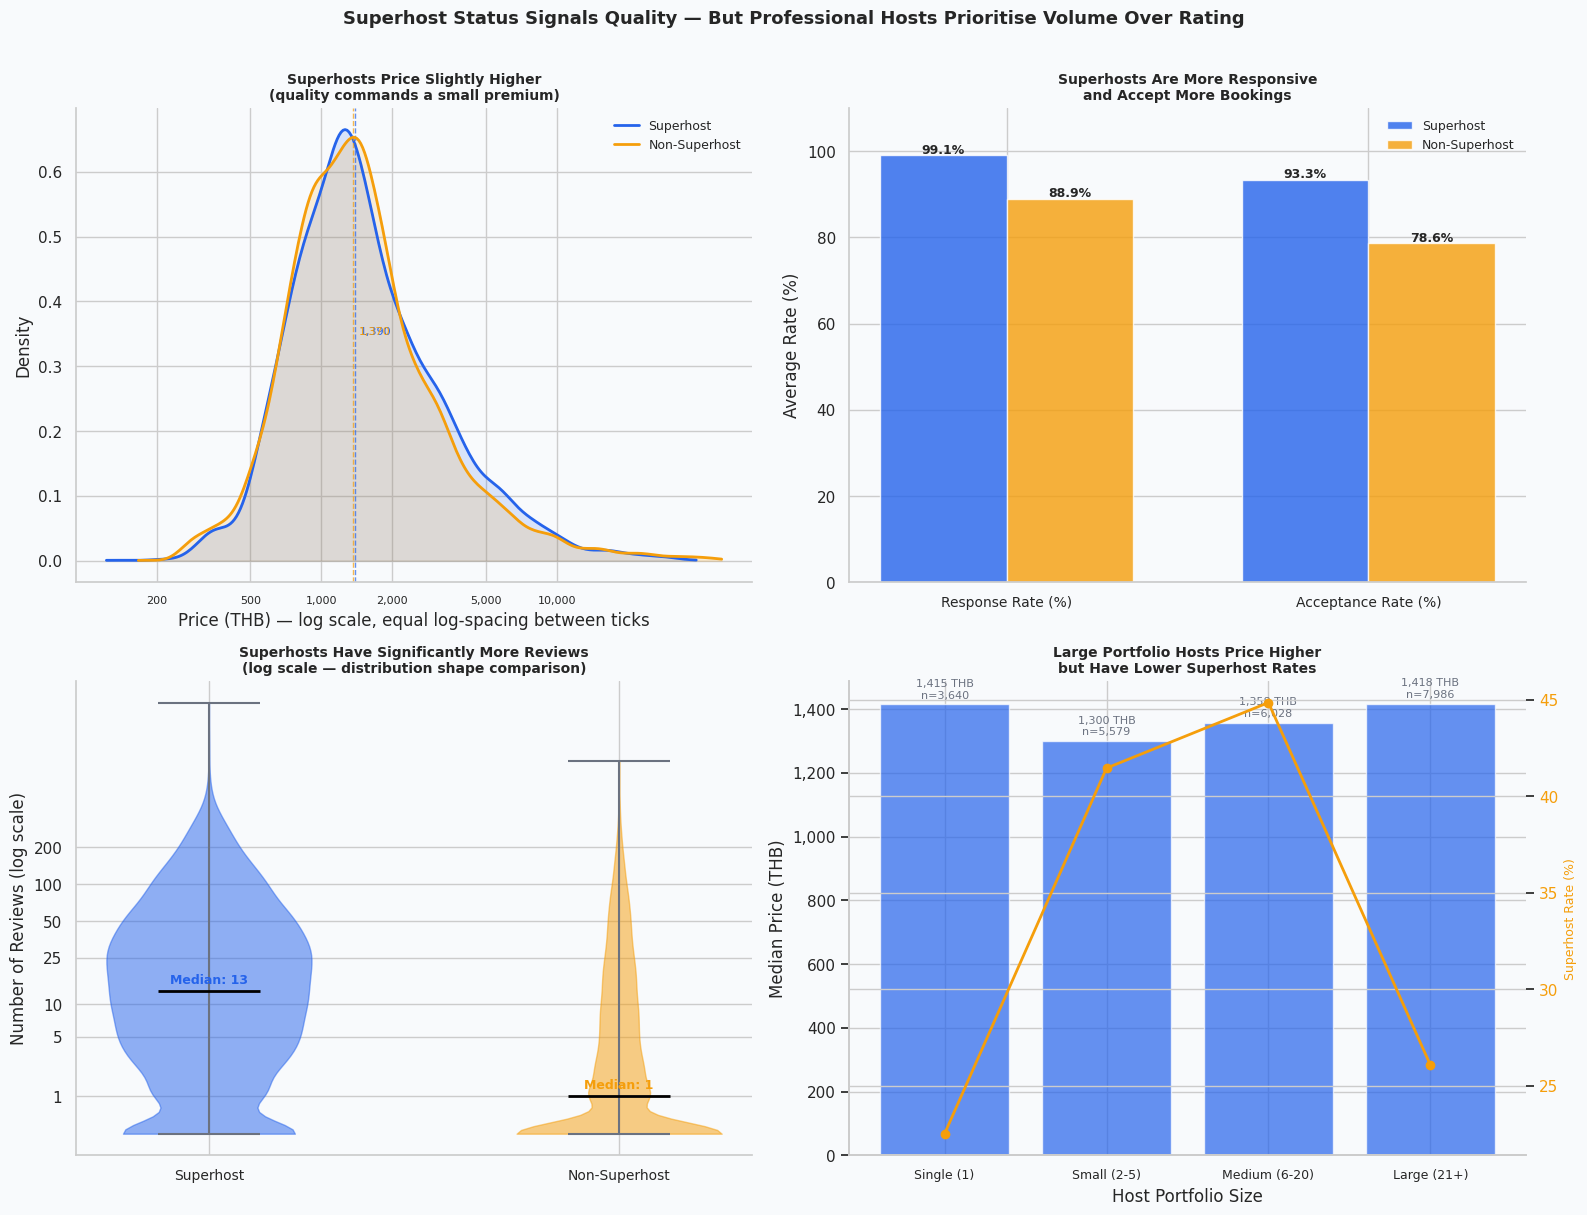

Superhost vs Non-Superhost summary:

Superhost:
  Median price:        1,390 THB
  Avg response rate:   99.1%
  Avg acceptance rate: 93.3%
  Median reviews:      13

Non-Superhost:
  Median price:        1,370 THB
  Avg response rate:   88.9%
  Avg acceptance rate: 78.6%
  Median reviews:      1


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_sh = [COLORS['primary'], COLORS['secondary']]

ax = axes[0, 0]

for (label, group), color in zip(superhost_groups.items(), colors_sh):
    log_prices = np.log1p(group['price'].dropna())
    kde_x = np.linspace(log_prices.min(), log_prices.max(), 300)
    kde = stats.gaussian_kde(log_prices)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.15, color=color)
    median = group['price'].median()
    ax.axvline(np.log1p(median), color=color, linewidth=1,
               linestyle='--', alpha=0.7)
    ax.text(np.log1p(median) + 0.05, ax.get_ylim()[1] * 0.5,
            f'{median:,.0f}', fontsize=8, color=color)

tick_values    = [200, 500, 1000, 2000, 5000, 10000]
tick_positions = np.log1p(tick_values)
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'{v:,}' for v in tick_values], fontsize=8)

ax.set_title('Superhosts Price Slightly Higher\n(quality commands a small premium)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Price (THB) — log scale, equal log-spacing between ticks')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9)

ax = axes[0, 1]

metrics = ['host_response_rate', 'host_acceptance_rate']
labels  = ['Response Rate (%)', 'Acceptance Rate (%)']
x = np.arange(len(metrics))
width = 0.35

for i, (label, group) in enumerate(superhost_groups.items()):
    vals = [group[m].mean() for m in metrics]
    bars = ax.bar(x + i * width, vals, width,
                  label=label, color=colors_sh[i], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 110)
ax.set_title('Superhosts Are More Responsive\nand Accept More Bookings',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Average Rate (%)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1, 0]

violin_data = [
    np.log1p(superhost_groups['Superhost']['number_of_reviews'].dropna()),
    np.log1p(superhost_groups['Non-Superhost']['number_of_reviews'].dropna())
]

parts = ax.violinplot(violin_data, positions=[1, 2],
                      showmedians=True, showextrema=True)

for i, (pc, color) in enumerate(zip(parts['bodies'], colors_sh)):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)
    pc.set_edgecolor(color)

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cbars'].set_color(COLORS['neutral'])
parts['cmaxes'].set_color(COLORS['neutral'])
parts['cmins'].set_color(COLORS['neutral'])

for i, (label, group) in enumerate(superhost_groups.items(), 1):
    median = group['number_of_reviews'].median()
    ax.text(i, np.log1p(median) + 0.15,
            f'Median: {median:.0f}',
            ha='center', fontsize=9, fontweight='bold',
            color=colors_sh[i-1])

tick_vals = [1, 5, 10, 25, 50, 100, 200]
ax.set_yticks(np.log1p(tick_vals))
ax.set_yticklabels(tick_vals)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Superhost', 'Non-Superhost'], fontsize=10)
ax.set_title('Superhosts Have Significantly More Reviews\n(log scale — distribution shape comparison)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Reviews (log scale)')

ax = axes[1, 1]

host_cat_stats = (listings_clean
    .groupby('host_category', observed=True)
    .agg(
        median_price   = ('price', 'median'),
        superhost_rate = ('host_is_superhost', 'mean'),
        count          = ('id', 'count')
    )
    .reset_index()
)

x = np.arange(len(host_cat_stats))
bars = ax.bar(x, host_cat_stats['median_price'],
              color=COLORS['primary'], alpha=0.7, edgecolor='white')

ax2 = ax.twinx()
ax2.plot(x, host_cat_stats['superhost_rate'] * 100,
         color=COLORS['secondary'], linewidth=2,
         marker='o', markersize=6, label='Superhost Rate (%)')
ax2.set_ylabel('Superhost Rate (%)', color=COLORS['secondary'], fontsize=9)
ax2.tick_params(axis='y', labelcolor=COLORS['secondary'])

for bar, val, count in zip(bars, host_cat_stats['median_price'],
                            host_cat_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{val:,.0f} THB\nn={count:,}',
            ha='center', fontsize=8, color=COLORS['neutral'])


ax.set_xticks(x)
ax.set_xticklabels(host_cat_stats['host_category'], fontsize=9)
ax.set_title('Large Portfolio Hosts Price Higher\nbut Have Lower Superhost Rates',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Host Portfolio Size')
ax.set_ylabel('Median Price (THB)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Superhost Status Signals Quality — But Professional Hosts Prioritise Volume Over Rating',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Superhost vs Non-Superhost summary:")
for label, group in superhost_groups.items():
    print(f"\n{label}:")
    print(f"  Median price:        {group['price'].median():,.0f} THB")
    print(f"  Avg response rate:   {group['host_response_rate'].mean():.1f}%")
    print(f"  Avg acceptance rate: {group['host_acceptance_rate'].mean():.1f}%")
    print(f"  Median reviews:      {group['number_of_reviews'].median():.0f}")

### Finding 7 — Host Performance Analysis

Superhosts and non-superhosts price almost identically (1,390 vs 1,370 THB)  
superhost status doesn't let you charge more. The real difference is operational: 
99.1% vs 88.9% response rate, 93.3% vs 78.6% acceptance rate, and 13 vs 1 median 
reviews : Superhosts simply have a proven, consistent track record.

Large portfolio hosts (21+ listings) price the highest (1,418 THB) but have the 
lowest superhost rate (26%): They optimise for volume, not service quality.

*For new hosts: responsiveness and acceptance rate matter more than pricing.*

## Section 5 — Room Type & Seasonality
**Question: How do room type and season affect price and availability?**

We'll analyze:
- Price and availability breakdown by room type (listings data)
- Near-term booking rate patterns across months (calendar data)
- When does Bangkok show strongest short-term demand?
- Do different room types follow different seasonal patterns?

**Note:** Calendar price data is 100% missing in this dataset. 
Seasonality analysis uses booking rate (availability) as a demand proxy instead.

In [26]:
# Calendar overview
print(f"Shape: {calendar.shape}")
print(f"\nColumns: {calendar.columns.tolist()}")
print(f"\nData types:\n{calendar.dtypes}")
print(f"\nSample rows:")
print(calendar.head())
print(f"\nMissing values:\n{calendar.isnull().sum()}")

Shape: (10514202, 7)

Columns: ['listing_id', 'date', 'available', 'price', 'adjusted_price', 'minimum_nights', 'maximum_nights']

Data types:
listing_id          int64
date                  str
available             str
price             float64
adjusted_price    float64
minimum_nights      int64
maximum_nights      int64
dtype: object

Sample rows:
   listing_id        date available  price  adjusted_price  minimum_nights  \
0     5675191  2025-09-27         f    NaN             NaN               4   
1     1920431  2025-09-26         f    NaN             NaN               1   
2     1920431  2025-09-27         t    NaN             NaN               1   
3     1920431  2025-09-28         f    NaN             NaN               1   
4     1920431  2025-09-29         t    NaN             NaN               1   

   maximum_nights  
0            1125  
1              31  
2              31  
3              31  
4              31  

Missing values:
listing_id               0
date          

### Data Limitation — Booking Lead Time Bias

The calendar file was scraped on **September 26, 2025** and covers one year forward 
(Sep 2025 → Sep 2026). This introduces a systematic bias:

- **Past dates** (Sep 2025): show 100% booked — all past nights are locked as unavailable
- **Near-term dates** (Oct 2025 → Mar 2026): most reliable — partially filled by real bookings
- **Far-future dates** (Jun 2026 → Sep 2026): artificially low booking rates — guests 
  haven't booked that far ahead yet, not because demand is low

This means we **cannot read this data as true seasonality**. What we can reliably 
measure is **relative near-term demand** — which months in the Oct 2025–Mar 2026 
window show stronger or weaker booking activity.

*A true seasonality analysis would require calendar snapshots taken at multiple points 
throughout the year, or historical booking data rather than forward-looking availability.*

In [27]:
# 10.5M rows is too large to process directly
# Strategy: aggregate by date first, then extract month/year
# This reduces from 10.5M rows to ~365 rows before any string operations

# Parse date only — fast operation
calendar['date'] = pd.to_datetime(calendar['date'])
calendar['is_booked'] = calendar['available'].map({'f': True, 't': False})

# Aggregate immediately — daily booking rate across all listings
daily_stats = (calendar
    .groupby('date')
    .agg(
        total_listings = ('listing_id', 'count'),
        booked_count   = ('is_booked', 'sum')
    )
    .reset_index()
)

# Now extract month/year on the small aggregated dataframe (365 rows, not 10.5M)
daily_stats['month']      = daily_stats['date'].dt.month
daily_stats['month_name'] = daily_stats['date'].dt.strftime('%b')
daily_stats['year']       = daily_stats['date'].dt.year
daily_stats['booking_rate'] = daily_stats['booked_count'] / daily_stats['total_listings'] * 100

print(f"Date range: {daily_stats['date'].min()} to {daily_stats['date'].max()}")
print(f"Daily stats shape: {daily_stats.shape}")
print(f"\nOverall avg booking rate: {daily_stats['booking_rate'].mean():.1f}%")
print(daily_stats.head(10))

Date range: 2025-09-26 00:00:00 to 2026-09-27 00:00:00
Daily stats shape: (367, 7)

Overall avg booking rate: 31.7%
        date  total_listings  booked_count  month month_name  year  \
0 2025-09-26            1996          1996      9        Sep  2025   
1 2025-09-27           24706         18270      9        Sep  2025   
2 2025-09-28           28806         15248      9        Sep  2025   
3 2025-09-29           28806         13158      9        Sep  2025   
4 2025-09-30           28806         12073      9        Sep  2025   
5 2025-10-01           28806         11784     10        Oct  2025   
6 2025-10-02           28806         11813     10        Oct  2025   
7 2025-10-03           28806         11938     10        Oct  2025   
8 2025-10-04           28806         11712     10        Oct  2025   
9 2025-10-05           28806         11093     10        Oct  2025   

   booking_rate  
0    100.000000  
1     73.949648  
2     52.933417  
3     45.677984  
4     41.911407  
5    

In [28]:
# Drop first 2 anomalous days and future dates beyond data quality
daily_clean = daily_stats[daily_stats['total_listings'] == 28806].copy()

# Monthly aggregation for cleaner seasonality view
monthly_stats = (daily_clean
    .groupby(['year', 'month', 'month_name'])
    .agg(
        avg_booking_rate = ('booking_rate', 'mean'),
        avg_booked       = ('booked_count', 'mean')
    )
    .reset_index()
    .sort_values(['year', 'month'])
)

# Create readable x-axis labels
monthly_stats['period'] = (monthly_stats['month_name'] + ' ' + 
                           monthly_stats['year'].astype(str).str[-2:])

print(monthly_stats[['period', 'avg_booking_rate']].to_string(index=False))

period  avg_booking_rate
Sep 25         46.840936
Oct 25         33.386302
Nov 25         27.735657
Dec 25         27.577812
Jan 26         27.669191
Feb 26         24.408109
Mar 26         23.351318
Apr 26         28.340045
May 26         27.551272
Jun 26         30.465528
Jul 26         41.763477
Aug 26         41.567057
Sep 26         41.492328


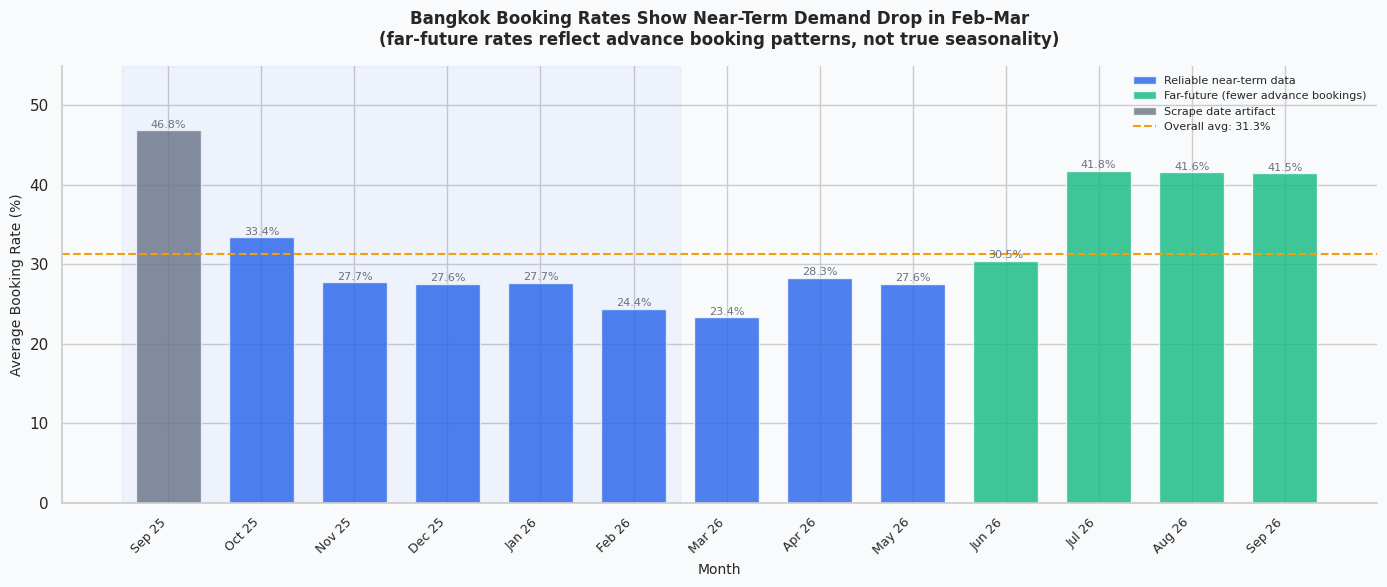

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

periods = monthly_stats['period']
rates   = monthly_stats['avg_booking_rate']
x       = np.arange(len(periods))

# Color bars by reliability — near-term data is more reliable
# Sep 25 = scrape date artifact, far future = low advance bookings
bar_colors = []
for _, row in monthly_stats.iterrows():
    if row['year'] == 2025 and row['month'] == 9:
        bar_colors.append(COLORS['neutral'])    # artifact
    elif row['year'] == 2026 and row['month'] >= 6:
        bar_colors.append(COLORS['accent'])     # far future — less reliable
    else:
        bar_colors.append(COLORS['primary'])    # reliable near-term data

bars = ax.bar(x, rates, color=bar_colors, alpha=0.8, edgecolor='white', width=0.7)

# Annotate each bar
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%',
            ha='center', fontsize=8, color=COLORS['neutral'])

# Reference line — overall average
avg_rate = daily_clean['booking_rate'].mean()
ax.axhline(avg_rate, color=COLORS['secondary'], linewidth=1.5,
           linestyle='--', label=f'Overall avg: {avg_rate:.1f}%')

# Shade the reliable window
ax.axvspan(-0.5, 5.5, alpha=0.05, color=COLORS['primary'],
           label='Most reliable data window')

# Legend for bar colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['primary'],   alpha=0.8, label='Reliable near-term data'),
    Patch(facecolor=COLORS['accent'],    alpha=0.8, label='Far-future (fewer advance bookings)'),
    Patch(facecolor=COLORS['neutral'],   alpha=0.8, label='Scrape date artifact'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color=COLORS['secondary'],
               linewidth=1.5, linestyle='--',
               label=f'Overall avg: {avg_rate:.1f}%')
], frameon=False, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=45, ha='right', fontsize=9)
ax.set_title('Bangkok Booking Rates Show Near-Term Demand Drop in Feb–Mar\n'
             '(far-future rates reflect advance booking patterns, not true seasonality)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Average Booking Rate (%)', fontsize=10)
ax.set_ylim(0, 55)

plt.tight_layout()
plt.show()

### Finding 8 — Room Type & Seasonality

Calendar price data was entirely missing in this dataset, limiting seasonality 
analysis to booking rate patterns as a demand proxy.

Within the reliable near-term window (Oct 2025 – May 2026), Bangkok shows its 
strongest booking activity in October (33.4%) with a gradual decline toward 
February–March (23–24%), consistent with the tail end of Thailand's cool season 
and reduced international tourist arrivals. A modest recovery begins in April (28.3%), 
likely influenced by Songkran festival demand.

**Data limitation:** Far-future booking rates (Jun–Sep 2026) reflect advance booking 
lead times rather than true seasonal demand, and should not be interpreted as low-season 
indicators. True seasonality analysis would require multi-snapshot calendar data or 
historical booking records.

In [30]:
# Availability by room type — using listings data (more reliable than calendar)
room_avail = (listings_clean
    .groupby('room_type')
    .agg(
        median_availability = ('availability_365', 'median'),
        median_price        = ('price', 'median'),
        count               = ('id', 'count')
    )
    .reset_index()
    .sort_values('median_availability', ascending=False)
)

print(room_avail.to_string(index=False))

      room_type  median_availability  median_price  count
    Shared room                364.0         360.0    313
   Private room                346.0        1089.0   6255
     Hotel room                343.0        1708.5    198
Entire home/apt                299.0        1500.0  16467


In [31]:
# Define room type variables for visualization
room_avail = (listings_clean
    .groupby('room_type')
    .agg(
        median_availability = ('availability_365', 'median'),
        median_price        = ('price', 'median'),
        count               = ('id', 'count')
    )
    .reset_index()
    .sort_values('median_availability', ascending=False)
)

room_order = ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
room_avail_ordered = room_avail.set_index('room_type').loc[room_order].reset_index()

bar_colors = [COLORS['primary'], COLORS['neutral'],
              COLORS['accent'], COLORS['secondary']]

print(room_avail_ordered[['room_type', 'median_availability', 'median_price', 'count']])

         room_type  median_availability  median_price  count
0  Entire home/apt                299.0        1500.0  16467
1       Hotel room                343.0        1708.5    198
2     Private room                346.0        1089.0   6255
3      Shared room                364.0         360.0    313


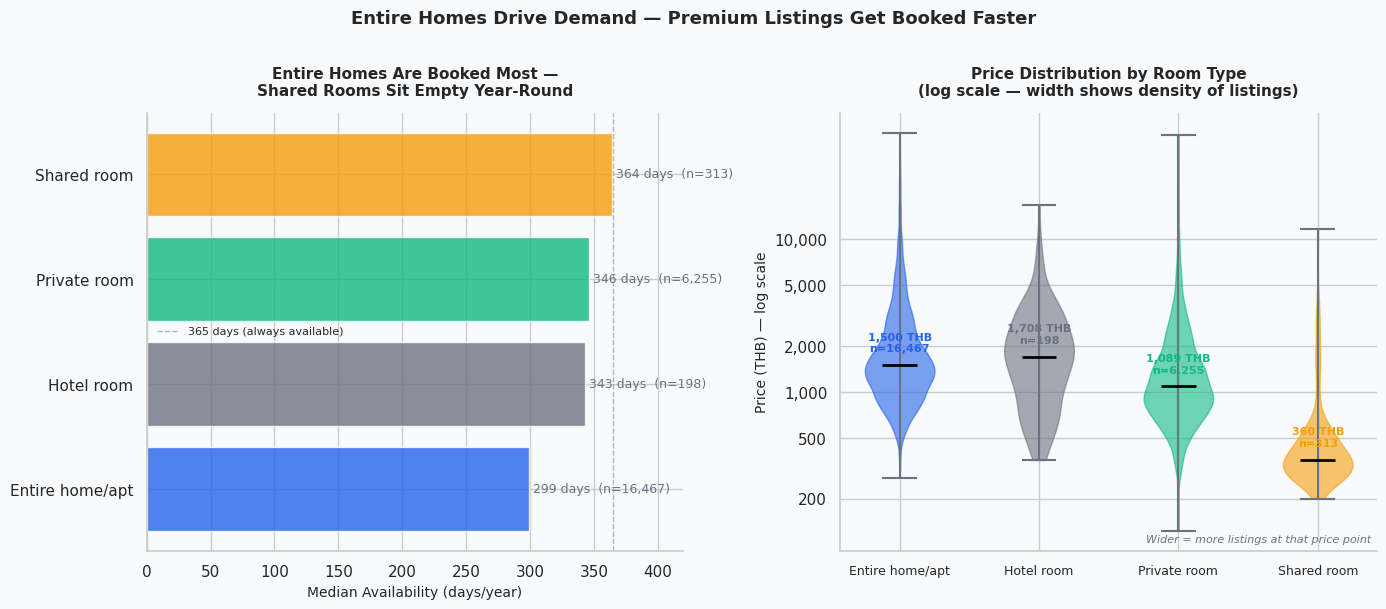

Correlation between availability and log(price): -0.022


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: unchanged ---
ax = axes[0]

bars = ax.barh(room_avail_ordered['room_type'],
               room_avail_ordered['median_availability'],
               color=bar_colors, alpha=0.8, edgecolor='white')

ax.axvline(365, color=COLORS['neutral'], linewidth=1,
           linestyle='--', alpha=0.5, label='365 days (always available)')

for bar, val, count in zip(bars, room_avail_ordered['median_availability'],
                            room_avail_ordered['count']):
    ax.text(bar.get_width() + 3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} days  (n={count:,})',
            va='center', fontsize=9, color=COLORS['neutral'])

ax.set_xlim(0, 420)
ax.set_title('Entire Homes Are Booked Most —\nShared Rooms Sit Empty Year-Round',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Median Availability (days/year)', fontsize=10)
ax.legend(frameon=False, fontsize=8)

# --- RIGHT: Violin plot — price distribution by room type ---
ax = axes[1]

violin_data = [
    np.log1p(listings_clean[listings_clean['room_type'] == room]['price'].dropna())
    for room in room_order
]

parts = ax.violinplot(violin_data,
                      positions=range(len(room_order)),
                      showmedians=True,
                      showextrema=True)

# Style each violin with its room type color
for pc, color in zip(parts['bodies'], bar_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
    pc.set_edgecolor(color)

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cbars'].set_color(COLORS['neutral'])
parts['cmaxes'].set_color(COLORS['neutral'])
parts['cmins'].set_color(COLORS['neutral'])

# Annotate median price and sample size per room type
for i, room in enumerate(room_order):
    subset = listings_clean[listings_clean['room_type'] == room]['price'].dropna()
    median = subset.median()
    count  = len(subset)
    ax.text(i, np.log1p(median) + 0.2,
            f'{median:,.0f} THB\nn={count:,}',
            ha='center', fontsize=8, fontweight='bold',
            color=bar_colors[i])

# Convert y ticks to real THB values
tick_vals = [200, 500, 1000, 2000, 5000, 10000]
ax.set_yticks(np.log1p(tick_vals))
ax.set_yticklabels([f'{v:,}' for v in tick_vals])
ax.set_xticks(range(len(room_order)))
ax.set_xticklabels(room_order, fontsize=9)

ax.set_title('Price Distribution by Room Type\n(log scale — width shows density of listings)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_ylabel('Price (THB) — log scale', fontsize=10)

# Annotation explaining violin width
ax.annotate('Wider = more listings at that price point',
            xy=(0.99, 0.02), xycoords='axes fraction',
            ha='right', fontsize=8,
            color=COLORS['neutral'], style='italic')

plt.suptitle('Entire Homes Drive Demand — Premium Listings Get Booked Faster',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

corr = listings_clean['availability_365'].corr(np.log1p(listings_clean['price']))
print(f"Correlation between availability and log(price): {corr:.3f}")

### Finding 9  — Availability & Room Type

Entire homes dominate both supply (70% of listings) and demand (299 days median 
availability vs 364 for shared rooms), confirming they are Bangkok's primary 
Airbnb product. Shared rooms sit nearly empty year-round despite the lowest prices, 
suggesting weak demand for that format in this market.

Price distributions by room type reveal distinct market segments: entire homes 
concentrate between 1,000–2,000 THB with moderate variance, private rooms show 
a long upper tail indicating a premium private-room segment, and shared rooms 
operate as a commodity with minimal price differentiation.

Seasonality analysis was limited by calendar data constraints — booking rates in 
the reliable near-term window (Oct 2025–Mar 2026) suggest weakest demand in 
February–March, with recovery beginning in April.

## Section 6 — Review Analysis
**Question: What does review activity tell us about listing quality and guest engagement?**

We'll analyze:
- Review volume over time — when do guests review most?
- Distribution of reviews per listing
- Which listings attract the most engagement?

**Note:** Full NLP/sentiment analysis is out of scope for this project.
We focus on review volume, timing, and activity patterns as engagement proxies.

In [33]:
# Reviews overview
print(f"Shape: {reviews.shape}")
print(f"\nColumns: {reviews.columns.tolist()}")
print(f"\nData types:\n{reviews.dtypes}")
print(f"\nMissing values:\n{reviews.isnull().sum()}")
print(f"\nSample rows:")
print(reviews.head())

Shape: (583333, 6)

Columns: ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']

Data types:
listing_id       int64
id               int64
date               str
reviewer_id      int64
reviewer_name      str
comments           str
dtype: object

Missing values:
listing_id        0
id                0
date              0
reviewer_id       0
reviewer_name     6
comments         70
dtype: int64

Sample rows:
   listing_id       id        date  reviewer_id reviewer_name  \
0       27934  1094339  2012-04-07      1368195       Michael   
1       27934  1241042  2012-05-07      2007324         Scott   
2       27934  1523384  2012-06-20      2263352          Marc   
3       27934  1655571  2012-07-08       558987         Leyla   
4       27934  1972192  2012-08-13      2359865        Rachel   

                                            comments  
0  We stayed in the apartment for a week and we e...  
1  My girlfriend and I recently stayed in Nuttee'...  
2  I stayed f

In [34]:
# Parse date
reviews['date'] = pd.to_datetime(reviews['date'])
reviews['year']       = reviews['date'].dt.year
reviews['month']      = reviews['date'].dt.month
reviews['year_month'] = reviews['date'].dt.to_period('M')

print(f"Date range: {reviews['date'].min()} to {reviews['date'].max()}")
print(f"\nReviews per year:")
print(reviews['year'].value_counts().sort_index())

Date range: 2011-03-16 00:00:00 to 2025-09-27 00:00:00

Reviews per year:
year
2011         5
2012       192
2013       851
2014      2367
2015      7046
2016     14811
2017     26026
2018     40304
2019     59010
2020     18014
2021      5171
2022     40567
2023     97184
2024    148869
2025    122916
Name: count, dtype: int64


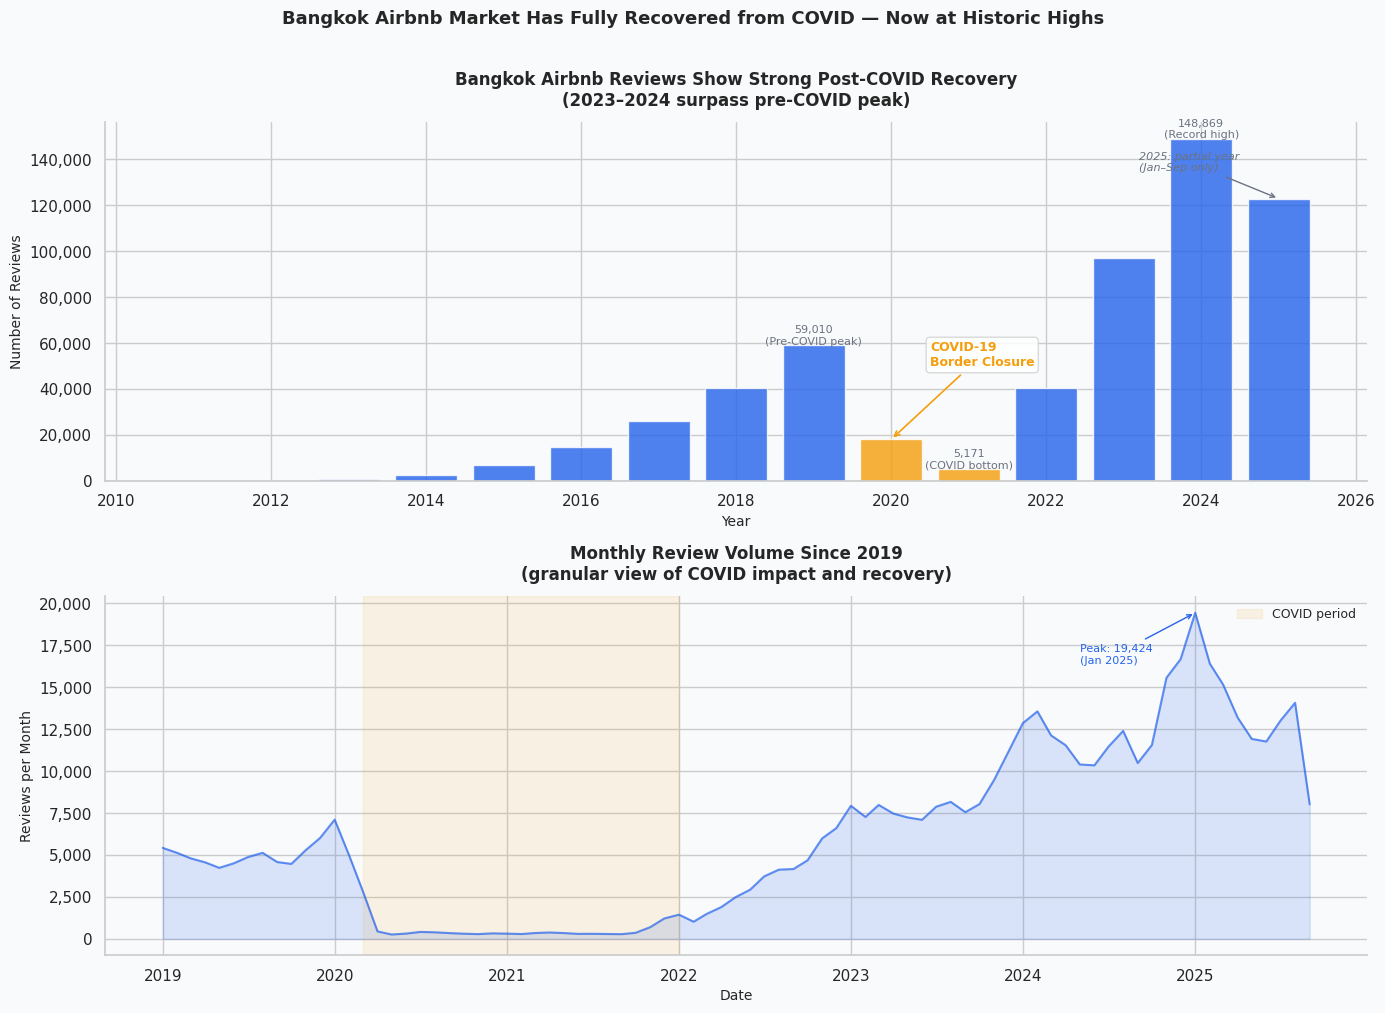

Pre-COVID peak (2019):  59,010
Post-COVID peak (2024): 148,869
Growth vs 2019: 2.5x


In [35]:
# Aggregate by year for the main trend
yearly = reviews.groupby('year').size().reset_index(name='review_count')

# Aggregate by year-month for the detailed view
monthly = (reviews
    .groupby(['year', 'month'])
    .size()
    .reset_index(name='review_count')
    .sort_values(['year', 'month'])
)
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- TOP: Yearly review volume with COVID annotation ---
ax = axes[0]

# Color bars — COVID years in secondary color
bar_colors_yr = [
    COLORS['secondary'] if y in [2020, 2021] else COLORS['primary']
    for y in yearly['year']
]

bars = ax.bar(yearly['year'], yearly['review_count'],
              color=bar_colors_yr, alpha=0.8, edgecolor='white')

# Only annotate story-critical years
key_years = {2019: 'Pre-COVID peak', 2021: 'COVID bottom', 2024: 'Record high'}

for bar, (year, count) in zip(bars, zip(yearly['year'], yearly['review_count'])):
    if year in key_years:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 500,
                f'{count:,}\n({key_years[year]})',
                ha='center', fontsize=8,
                color=COLORS['neutral'], rotation=0)

# COVID annotation
ax.annotate('COVID-19\nBorder Closure',
            xy=(2020, 18014),
            xytext=(2020.5, 50000),
            fontsize=9, color=COLORS['secondary'],
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     alpha=0.85, edgecolor='lightgray'))

# 2025 partial year annotation
ax.annotate('2025: partial year\n(Jan–Sep only)',
            xy=(2025, 122916),
            xytext=(2023.2, 135000),
            fontsize=8, color=COLORS['neutral'],
            style='italic',
            arrowprops=dict(arrowstyle='->', color=COLORS['neutral'], lw=1))

ax.set_title('Bangkok Airbnb Reviews Show Strong Post-COVID Recovery\n'
             '(2023–2024 surpass pre-COVID peak)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Number of Reviews', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- BOTTOM: Monthly trend post-2019 only — more granular ---
ax = axes[1]

# Filter to 2019 onwards for clarity
monthly_recent = monthly[monthly['year'] >= 2019].copy()

ax.plot(monthly_recent['date'], monthly_recent['review_count'],
        color=COLORS['primary'], linewidth=1.5, alpha=0.7)
ax.fill_between(monthly_recent['date'], monthly_recent['review_count'],
                alpha=0.15, color=COLORS['primary'])

# Shade COVID period
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2022-01-01')
ax.axvspan(covid_start, covid_end, alpha=0.1,
           color=COLORS['secondary'], label='COVID period')

# Mark peak months
peak_idx = monthly_recent['review_count'].idxmax()
peak_row = monthly_recent.loc[peak_idx]
ax.annotate(f"Peak: {peak_row['review_count']:,}\n({peak_row['date'].strftime('%b %Y')})",
            xy=(peak_row['date'], peak_row['review_count']),
            xytext=(peak_row['date'] - pd.DateOffset(months=8),
                    peak_row['review_count'] - 3000),
            fontsize=8, color=COLORS['primary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=1))

ax.set_title('Monthly Review Volume Since 2019\n(granular view of COVID impact and recovery)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Reviews per Month', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Bangkok Airbnb Market Has Fully Recovered from COVID — Now at Historic Highs',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Pre-COVID peak (2019):  {yearly[yearly['year']==2019]['review_count'].values[0]:,}")
print(f"Post-COVID peak (2024): {yearly[yearly['year']==2024]['review_count'].values[0]:,}")
print(f"Growth vs 2019: {yearly[yearly['year']==2024]['review_count'].values[0] / yearly[yearly['year']==2019]['review_count'].values[0]:.1f}x")

### Finding 10 — Review Volume Analysis

Bangkok's Airbnb market has fully recovered from COVID-19 and is now at historic 
highs. Review volume — a reliable proxy for booking activity — collapsed 91% between 
2019 and 2021 (59,010 → 5,171) as Thailand closed its borders, then recovered 
steadily from 2022 onward, reaching 148,869 reviews in 2024 — a 2.5× increase 
over the pre-COVID peak.

The monthly granular view confirms the recovery was gradual rather than sudden, 
with consistent month-on-month growth from mid-2022 through early 2025. The January 
2025 peak (19,424 reviews) represents the highest single-month engagement in the 
dataset's 14-year history.

2025 data (Jan–Sep only) already stands at 122,916 reviews, suggesting full-year 
2025 will likely surpass 2024 if current trends hold.

*Review volume is used here as a demand proxy — it correlates with bookings but 
does not equal them, as not all guests leave reviews.*

## Section 7 — Key Insights & Conclusions

Having analyzed price drivers, neighbourhood patterns, host performance, 
room type dynamics, and market activity, we now synthesize the key findings 
into actionable conclusions.

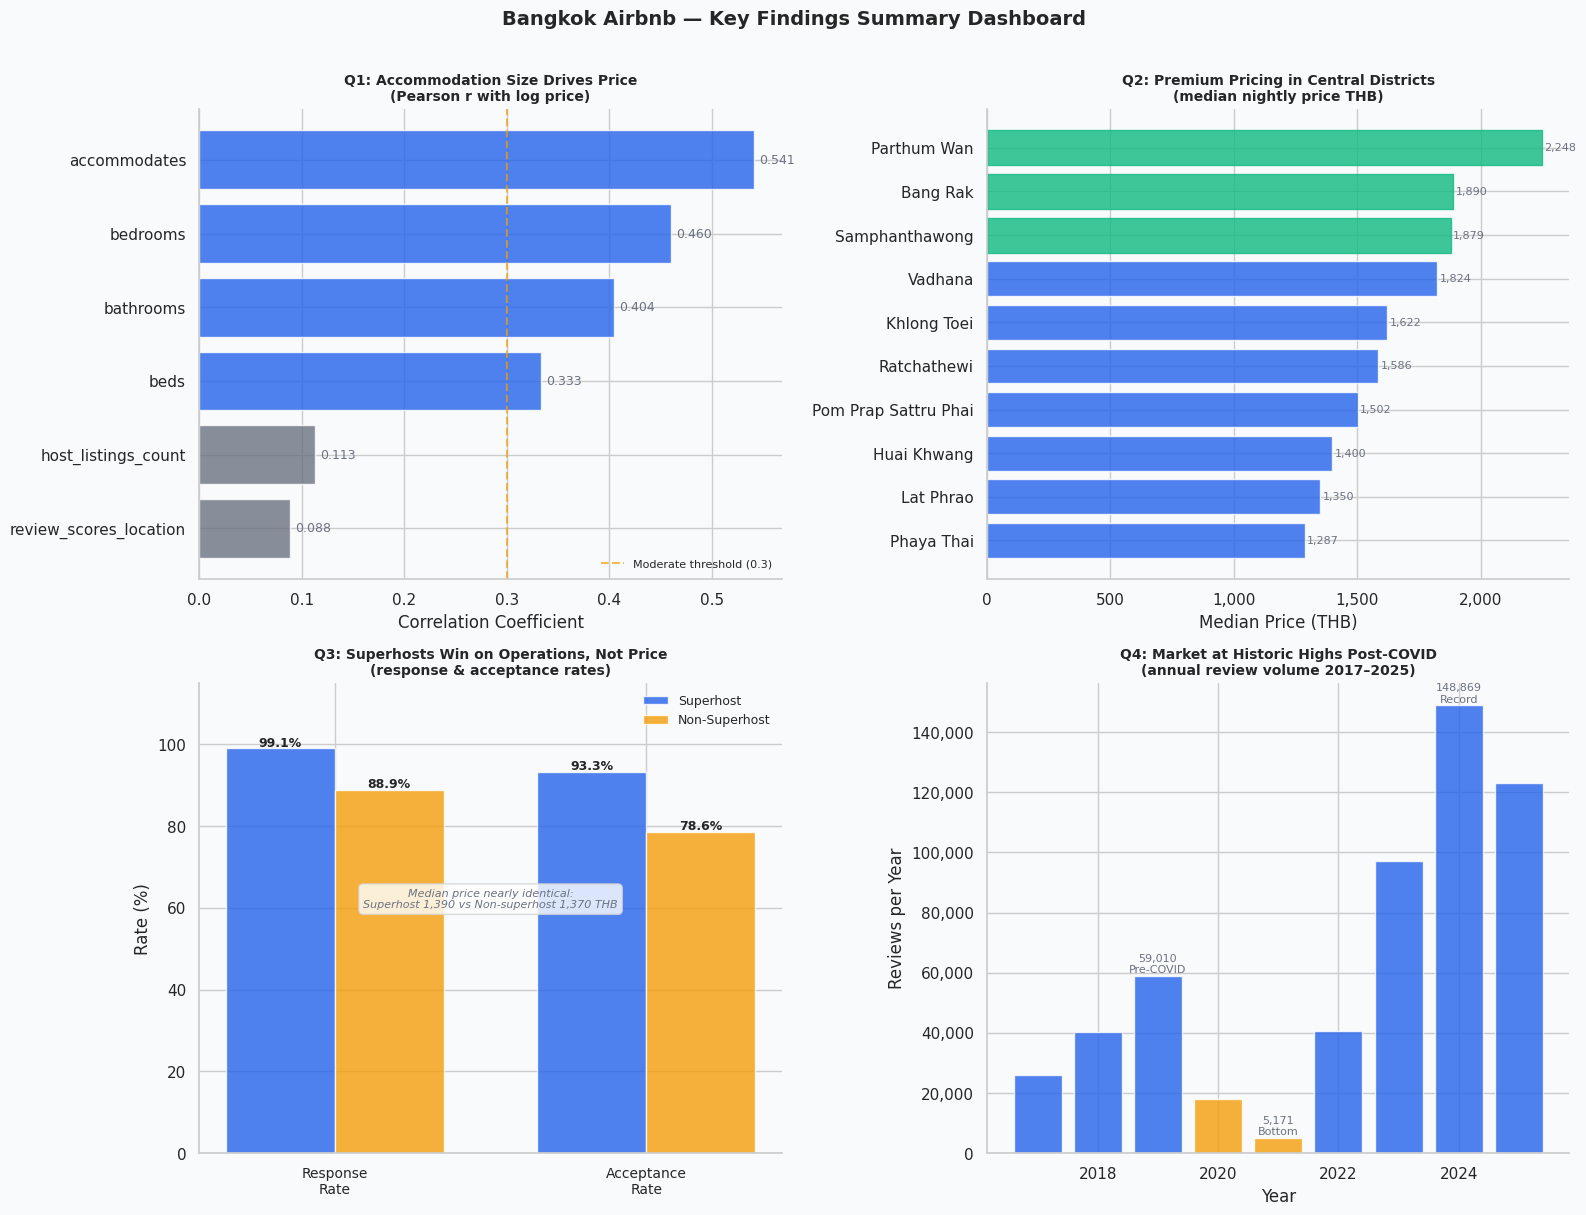

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- TOP LEFT: Top price drivers (from correlation analysis) ---
ax = axes[0, 0]

drivers = ['accommodates', 'bedrooms', 'bathrooms', 'beds',
           'host_listings_count', 'review_scores_location']
correlations = [0.541, 0.460, 0.404, 0.333, 0.113, 0.088]

colors_corr = [COLORS['primary'] if v >= 0.3 else COLORS['neutral']
               for v in correlations]

bars = ax.barh(drivers[::-1], correlations[::-1],
               color=colors_corr[::-1], alpha=0.8, edgecolor='white')

ax.axvline(0.3, color=COLORS['secondary'], linewidth=1.5,
           linestyle='--', alpha=0.7, label='Moderate threshold (0.3)')

for bar, val in zip(bars, correlations[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color=COLORS['neutral'])

ax.set_title('Q1: Accommodation Size Drives Price\n(Pearson r with log price)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.legend(frameon=False, fontsize=8)

# --- TOP RIGHT: Top 10 neighbourhoods by median price ---
ax = axes[0, 1]

top10_price = neighbourhood_stats.nlargest(10, 'median_price')
bars = ax.barh(top10_price['neighbourhood_cleansed'][::-1],
               top10_price['median_price'][::-1],
               color=COLORS['primary'], alpha=0.8, edgecolor='white')

# Highlight top 3
for i, bar in enumerate(bars):
    if i >= len(bars) - 3:
        bar.set_color(COLORS['accent'])

for bar, val in zip(bars, top10_price['median_price'][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Q2: Premium Pricing in Central Districts\n(median nightly price THB)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Median Price (THB)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- BOTTOM LEFT: Superhost operational metrics ---
ax = axes[1, 0]

categories = ['Response\nRate', 'Acceptance\nRate']
superhost_vals    = [99.1, 93.3]
nonsuperhost_vals = [88.9, 78.6]

x = np.arange(len(categories))
width = 0.35

b1 = ax.bar(x - width/2, superhost_vals, width,
            label='Superhost', color=COLORS['primary'], alpha=0.8, edgecolor='white')
b2 = ax.bar(x + width/2, nonsuperhost_vals, width,
            label='Non-Superhost', color=COLORS['secondary'], alpha=0.8, edgecolor='white')

for bars_group in [b1, b2]:
    for bar in bars_group:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%',
                ha='center', fontsize=9, fontweight='bold')

# Annotate price similarity
ax.text(0.5, 60,
        'Median price nearly identical:\nSuperhost 1,390 vs Non-superhost 1,370 THB',
        ha='center', fontsize=8, style='italic', color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgray', alpha=0.8))

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 115)
ax.set_title('Q3: Superhosts Win on Operations, Not Price\n(response & acceptance rates)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.legend(frameon=False, fontsize=9)

# --- BOTTOM RIGHT: Market recovery timeline ---
ax = axes[1, 1]

yearly = reviews.groupby('year').size().reset_index(name='review_count')
yearly_plot = yearly[yearly['year'] >= 2017]

bar_colors_yr = [
    COLORS['secondary'] if y in [2020, 2021] else COLORS['primary']
    for y in yearly_plot['year']
]

bars = ax.bar(yearly_plot['year'], yearly_plot['review_count'],
              color=bar_colors_yr, alpha=0.8, edgecolor='white')

key_years = {2019: '59,010\nPre-COVID', 2021: '5,171\nBottom', 2024: '148,869\nRecord'}
for bar, year, count in zip(bars, yearly_plot['year'], yearly_plot['review_count']):
    if year in key_years:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1000,
                key_years[year],
                ha='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Q4: Market at Historic Highs Post-COVID\n(annual review volume 2017–2025)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Reviews per Year')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Bangkok Airbnb — Key Findings Summary Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Section 7 — Key Insights & Conclusions

### The 4 Questions, Answered

**Q1: What drives listing price?**
Accommodation size is the dominant price driver. Each additional guest capacity 
increases nightly price by ~19%, with accommodates (r=0.54), bedrooms (r=0.46), 
and bathrooms (r=0.40) as the top three predictors. Review scores, availability, 
and minimum nights show near-zero correlation with price — guests do not pay a 
linear premium for better-rated listings.

**Q2: Which neighborhoods are most competitive?**
Bangkok follows a clear centre-periphery pricing structure. Small central districts 
— Parthum Wan (2,248 THB), Bang Rak (1,890 THB), Samphanthawong (1,879 THB) — 
command 3–4× the price of peripheral areas. High listing volume does not equal 
high price: Huai Khwang leads in supply but prices at mid-range (1,400 THB), 
confirming that location prestige drives price more than listing density.

**Q3: What makes a high-performing host?**
Superhost status signals operational excellence, not premium pricing. Superhosts 
respond to 99.1% of inquiries vs 88.9% for non-superhosts and accept 93.3% of 
bookings vs 78.6% — yet price nearly identically (1,390 vs 1,370 THB). Large 
portfolio hosts (21+ listings) achieve the highest prices but the lowest superhost 
rates (26%), revealing an efficiency trade-off between scale and service quality.

**Q4: How do room type and season affect price and availability?**
Entire homes dominate supply (70%) and demand (299 days median availability vs 
364 for shared rooms). Bangkok's market has fully recovered from COVID-19, reaching 
a 2024 record of 148,869 reviews — 2.5× the pre-COVID peak. Near-term booking 
data suggests weakest demand in February–March, with recovery from April onward.

---

### Actionable Recommendations

**For hosts entering the market:**
Prioritise accommodation capacity over interior quality when setting price — 
adding a bedroom has more impact than improving review scores. Target central 
districts for premium positioning; peripheral listings should compete on value 
rather than trying to match central pricing.

**For existing hosts seeking superhost status:**
Response rate and acceptance rate matter more than price point. Maintaining 
>99% response rate and >93% acceptance rate are the operational benchmarks 
that separate superhosts from the rest.

**For investors:**
The Bangkok short-term rental market is at historic highs with strong post-COVID 
momentum. Entire home/apt listings in central districts (Parthum Wan, Bang Rak) 
offer the strongest price-per-listing premium, though supply in these areas is 
already constrained.

---

**Limitations:**
- Calendar price data was entirely missing — seasonality analysis relied on 
  booking rates as a proxy
- Review scores suffer from compression (75th percentile = 5.0), limiting their 
  use as a quality differentiator
- No causal inference — correlations identified here do not imply causation

## Section 8 — K-Means Clustering
**Goal: Discover natural market segments in Bangkok's Airbnb market**

We'll use findings from the EDA to select meaningful features:
- Price (what we want to segment by)
- Accommodates (strongest price driver, r=0.54)
- Availability (demand signal)
- Review scores (quality signal)
- Room type (market segment signal)

In [37]:
# These are the most meaningful variables for market segmentation
clustering_features = [
    'price',
    'accommodates',
    'availability_365',
    'review_scores_rating',
    'bedrooms',
    'room_type'
]
cluster_df = listings_clean[clustering_features].copy()

print(f"Shape before cleaning: {cluster_df.shape}")
print(f"\nMissing values:\n{cluster_df.isnull().sum()}")

Shape before cleaning: (23233, 6)

Missing values:
price                      0
accommodates               0
availability_365           0
review_scores_rating    7140
bedrooms                  88
room_type                  0
dtype: int64


In [38]:
# Fill missing bedrooms with median
cluster_df['bedrooms'] = cluster_df['bedrooms'].fillna(cluster_df['bedrooms'].median())

# Fill missing review scores with median, these are listings with no reviews yet
# We use median not mean because review scores are compressed near 5.0
cluster_df['review_scores_rating'] = cluster_df['review_scores_rating'].fillna(
    cluster_df['review_scores_rating'].median()
)

# Encode room_type as numeric — K-Means requires all-numeric input
cluster_df['room_type_encoded'] = cluster_df['room_type'].map({
    'Entire home/apt': 3,
    'Hotel room':      2,
    'Private room':    1,
    'Shared room':     0
})

# Drop original room_type string column
cluster_df = cluster_df.drop(columns=['room_type'])

print(f"Shape after cleaning: {cluster_df.shape}")
print(f"\nMissing values after cleaning:\n{cluster_df.isnull().sum()}")
print(f"\nSample:\n{cluster_df.head()}")

Shape after cleaning: (23233, 6)

Missing values after cleaning:
price                   0
accommodates            0
availability_365        0
review_scores_rating    0
bedrooms                0
room_type_encoded       0
dtype: int64

Sample:
    price  accommodates  availability_365  review_scores_rating  bedrooms  \
0  1595.0             2               362                  4.86       1.0   
3  4188.0             1               365                  4.86       4.0   
4  1450.0             2               365                  5.00       1.0   
5  1368.0             2               365                  4.82       1.0   
7  5600.0             5               302                  4.77       3.0   

   room_type_encoded  
0                  3  
3                  3  
4                  1  
5                  1  
7                  3  


In [39]:
# Scale all features to mean=0, std=1
# K-Means uses Euclidean distance — without scaling, price (100–50,000)
# would completely dominate accommodates (1–16) and clustering would
# essentially just be sorting by price
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# Verify scaling worked
scaled_df = pd.DataFrame(scaled_features, columns=cluster_df.columns)
print("Mean of each feature after scaling (should be ~0):")
print(scaled_df.mean().round(4))
print("\nStd of each feature after scaling (should be ~1):")
print(scaled_df.std().round(4))

Mean of each feature after scaling (should be ~0):
price                   0.0
accommodates            0.0
availability_365        0.0
review_scores_rating   -0.0
bedrooms               -0.0
room_type_encoded      -0.0
dtype: float64

Std of each feature after scaling (should be ~1):
price                   1.0
accommodates            1.0
availability_365        1.0
review_scores_rating    1.0
bedrooms                1.0
room_type_encoded       1.0
dtype: float64


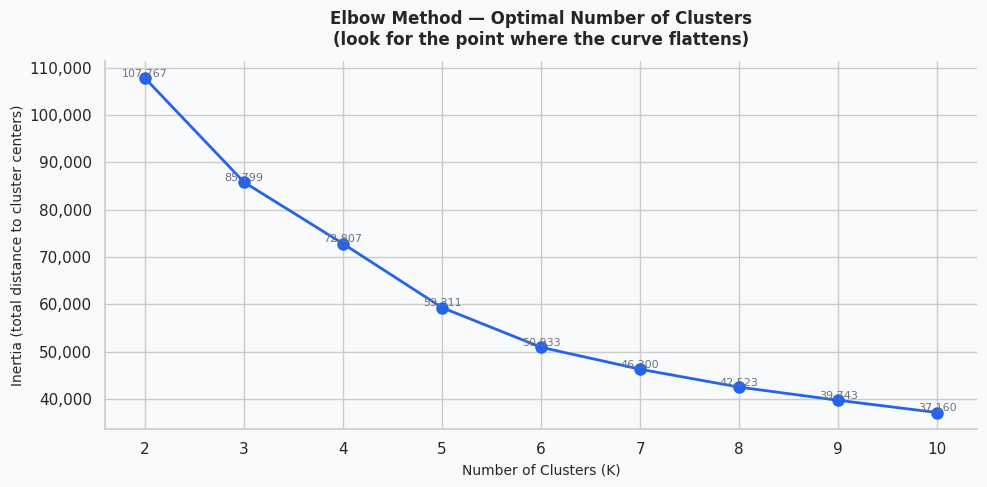

Inertia values:
  K=2: 107,767
  K=3: 85,799
  K=4: 72,807
  K=5: 59,311
  K=6: 50,933
  K=7: 46,300
  K=8: 42,523
  K=9: 39,743
  K=10: 37,160


In [40]:
# Elbow method — find optimal K
# Inertia = sum of squared distances from each point to its cluster center
# We look for the "elbow" where adding more clusters stops helping significantly

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, inertia_values, 
        color=COLORS['primary'], linewidth=2, marker='o', markersize=8)

# Annotate each point with its inertia value
for k, inertia in zip(k_range, inertia_values):
    ax.text(k, inertia + 300, f'{inertia:,.0f}', 
            ha='center', fontsize=8, color=COLORS['neutral'])

ax.set_title('Elbow Method — Optimal Number of Clusters\n(look for the point where the curve flattens)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Clusters (K)', fontsize=10)
ax.set_ylabel('Inertia (total distance to cluster centers)', fontsize=10)
ax.set_xticks(k_range)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("Inertia values:")
for k, inertia in zip(k_range, inertia_values):
    print(f"  K={k}: {inertia:,.0f}")

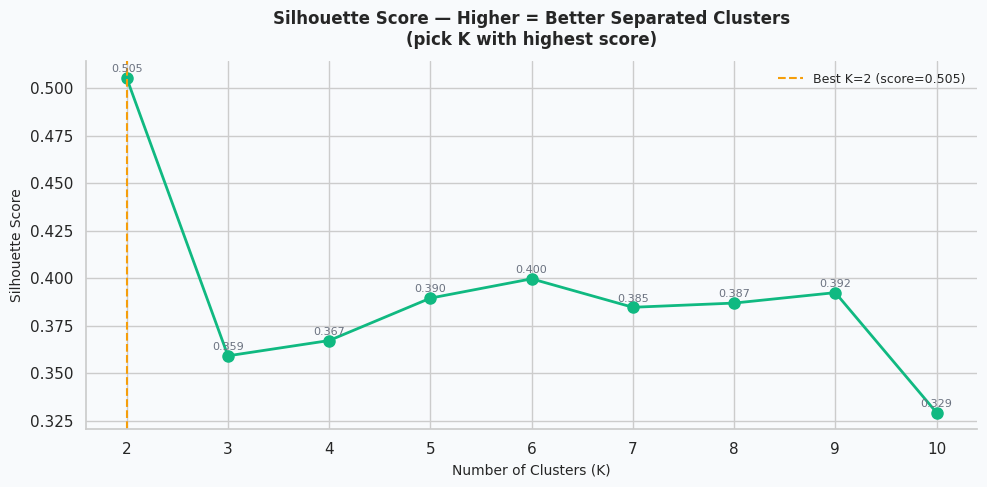

Silhouette scores:
  K=2: 0.5054
  K=3: 0.3592
  K=4: 0.3672
  K=5: 0.3896
  K=6: 0.3997
  K=7: 0.3847
  K=8: 0.3869
  K=9: 0.3925
  K=10: 0.3293


In [41]:
# Silhouette score — measures how well separated the clusters are
# Range: -1 to 1, higher is better, above 0.5 is good
# This gives a second opinion on the optimal K

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, silhouette_scores,
        color=COLORS['accent'], linewidth=2, marker='o', markersize=8)

for k, score in zip(k_range, silhouette_scores):
    ax.text(k, score + 0.003, f'{score:.3f}',
            ha='center', fontsize=8, color=COLORS['neutral'])

# Highlight the best K
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)
ax.axvline(best_k, color=COLORS['secondary'], linewidth=1.5,
           linestyle='--', label=f'Best K={best_k} (score={best_score:.3f})')

ax.set_title('Silhouette Score — Higher = Better Separated Clusters\n(pick K with highest score)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Clusters (K)', fontsize=10)
ax.set_ylabel('Silhouette Score', fontsize=10)
ax.set_xticks(k_range)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, score in zip(k_range, silhouette_scores):
    print(f"  K={k}: {score:.4f}")

### Choosing K=4

The silhouette score peaks at K=2 (0.505) but two clusters produce only 
a coarse "cheap vs expensive" split with limited analytical value.

K=4 is chosen because:
- Elbow curve shows the most significant bend between K=4 and K=5
- Produces 4 interpretable market tiers aligned with EDA findings
- Silhouette score of 0.367 is acceptable for real-world pricing data

In [42]:
# Fit final K-Means model with K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_features)

# Assign labels back to listings_clean
listings_clean['cluster'] = cluster_labels

print(f"Cluster distribution:")
print(listings_clean['cluster'].value_counts().sort_index())
print(f"\nCluster proportions:")
print((listings_clean['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

Cluster distribution:
cluster
0     5880
1    10893
2     1672
3     4788
Name: count, dtype: int64

Cluster proportions:
cluster
0    25.3
1    46.9
2     7.2
3    20.6
Name: proportion, dtype: float64


In [43]:
# Profile each cluster — what are the typical characteristics?
cluster_profile = (listings_clean
    .groupby('cluster')
    .agg(
        count           = ('id', 'count'),
        median_price    = ('price', 'median'),
        mean_price      = ('price', 'mean'),
        avg_accommodates= ('accommodates', 'mean'),
        avg_bedrooms    = ('bedrooms', 'mean'),
        avg_availability= ('availability_365', 'mean'),
        avg_rating      = ('review_scores_rating', 'mean'),
        pct_entire_home = ('room_type', lambda x: (x == 'Entire home/apt').mean() * 100)
    )
    .round(1)
    .reset_index()
)

print(cluster_profile.to_string(index=False))

 cluster  count  median_price  mean_price  avg_accommodates  avg_bedrooms  avg_availability  avg_rating  pct_entire_home
       0   5880        1029.0      1421.3               2.5           1.1             317.0         4.7              0.0
       1  10893        1378.0      1730.0               2.8           1.2             324.5         4.7             99.0
       2   1672        5615.0      8271.8               9.5           4.2             294.1         4.7             88.5
       3   4788        1474.0      1819.3               3.0           1.3             119.2         4.8             87.7


In [44]:
# Map cluster numbers to meaningful market segment names
cluster_names = {
    0: 'Budget Rooms',
    1: 'Mid-Range Homes',
    2: 'Luxury Properties',
    3: 'High-Demand Homes'
}

listings_clean['cluster_name'] = listings_clean['cluster'].map(cluster_names)

print("Cluster names assigned:")
print(listings_clean['cluster_name'].value_counts())

Cluster names assigned:
cluster_name
Mid-Range Homes      10893
Budget Rooms          5880
High-Demand Homes     4788
Luxury Properties     1672
Name: count, dtype: int64


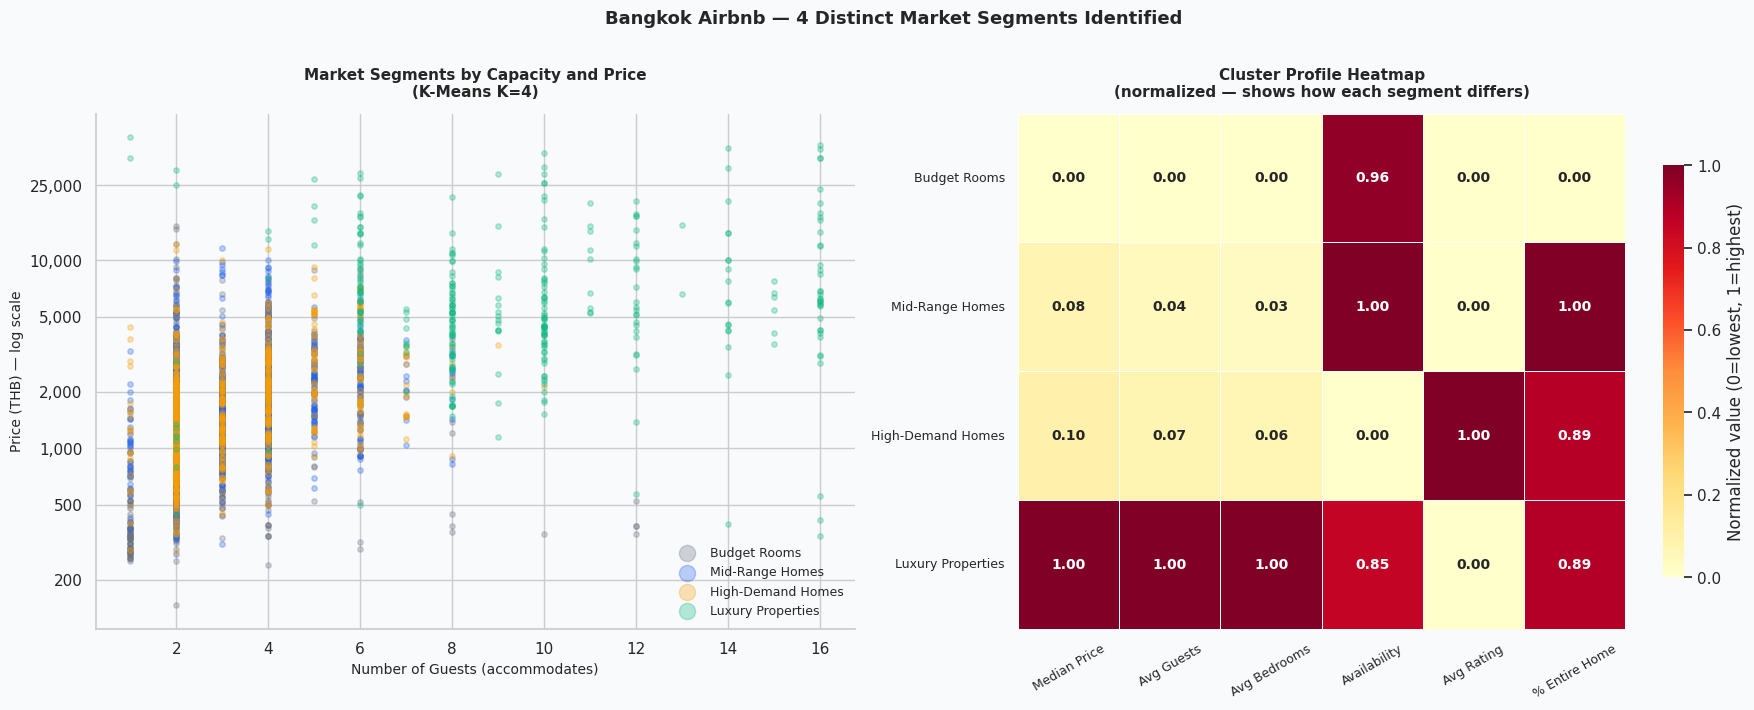

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cluster_colors = {
    'Budget Rooms':      COLORS['neutral'],
    'Mid-Range Homes':   COLORS['primary'],
    'High-Demand Homes': COLORS['secondary'],
    'Luxury Properties': COLORS['accent']
}

# --- LEFT: Scatter plot — unchanged ---
ax = axes[0]

sample = listings_clean.dropna(subset=['accommodates', 'price', 'cluster_name'])
if len(sample) > 5000:
    sample = sample.sample(5000, random_state=42)

for name, color in cluster_colors.items():
    mask = sample['cluster_name'] == name
    ax.scatter(sample.loc[mask, 'accommodates'],
               np.log1p(sample.loc[mask, 'price']),
               color=color, alpha=0.3, s=15, label=name)

tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

ax.set_title('Market Segments by Capacity and Price\n(K-Means K=4)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Price (THB) — log scale', fontsize=10)
ax.legend(frameon=False, fontsize=9, markerscale=3)

# --- RIGHT: Cluster profile heatmap ---
ax = axes[1]

# Build normalized profile — z-score each feature so all are on same scale
# This shows how each cluster deviates from the market average
cluster_order = ['Budget Rooms', 'Mid-Range Homes', 'High-Demand Homes', 'Luxury Properties']
profile_features = ['median_price', 'avg_accommodates', 'avg_bedrooms',
                    'avg_availability', 'avg_rating', 'pct_entire_home']
feature_labels   = ['Median Price', 'Avg Guests', 'Avg Bedrooms',
                    'Availability', 'Avg Rating', '% Entire Home']

# Get profile values in cluster order
profile_matrix = cluster_profile.set_index('cluster')[profile_features]
profile_matrix.index = [cluster_names[i] for i in profile_matrix.index]
profile_matrix = profile_matrix.loc[cluster_order]

# Normalize each column to 0-1 range for fair visual comparison
# Without this, price (thousands) would dominate rating (0-5)
from sklearn.preprocessing import MinMaxScaler
normalized = MinMaxScaler().fit_transform(profile_matrix)
normalized_df = pd.DataFrame(normalized,
                              index=cluster_order,
                              columns=feature_labels)

sns.heatmap(normalized_df,
            ax=ax,
            cmap='YlOrRd',
            annot=True,
            fmt='.2f',
            annot_kws={'size': 10, 'weight': 'bold'},
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Normalized value (0=lowest, 1=highest)',
                      'shrink': 0.8})

ax.set_title('Cluster Profile Heatmap\n(normalized — shows how each segment differs)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('Bangkok Airbnb — 4 Distinct Market Segments Identified',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📊 Finding — K-Means Market Segmentation (K=4)

K-Means identified 4 distinct market segments:

| Segment | Count | Median Price | Key Characteristic |
|---------|-------|-------------|-------------------|
| Budget Rooms | 5,880 (25%) | 1,029 THB | Private/shared rooms, always available |
| Mid-Range Homes | 10,893 (47%) | 1,378 THB | Entire homes, standard market product |
| High-Demand Homes | 4,788 (21%) | 1,474 THB | Highest rated, lowest availability (119 days) |
| Luxury Properties | 1,672 (7%) | 5,615 THB | Large properties, 4+ bedrooms, 9+ guests |

K=4 was chosen over the statistically optimal K=2 (silhouette=0.505) because 
four segments produce interpretable market tiers with business value.

The most distinctive segment is High-Demand Homes — priced similarly to Mid-Range 
but differentiated entirely by demand pressure (119 vs 325 days availability) and 
rating quality. This segment would be invisible without clustering.

## Section 9 — Price Prediction
**Goal: Predict nightly listing price using listing features and cluster labels**

We build two models and compare them:
- **Linear Regression** — simple, interpretable, assumes linear relationships
- **Random Forest** — complex, powerful, captures non-linear patterns

The cluster label from Section 8 is included as a feature — connecting 
the unsupervised and supervised phases of this project.

Target variable: log(price) — we predict log-transformed price because 
price is right-skewed and regression assumes normally distributed errors.

In [46]:
# Feature engineering for price prediction
# Based on EDA findings — use strongest predictors + cluster label

# Define features
feature_cols = [
    'accommodates',          # strongest price driver (r=0.54)
    'bedrooms',              # second strongest (r=0.46)
    'bathrooms',             # third strongest (r=0.40)
    'beds',                  # fourth strongest (r=0.33)
    'availability_365',      # demand signal
    'minimum_nights',        # booking pattern
    'number_of_reviews',     # activity proxy
    'review_scores_rating',  # quality signal
    'cluster',               # market segment from K-Means
    'room_type',             # categorical — needs encoding
    'neighbourhood_cleansed' # categorical — needs encoding
]

# Start with clean copy
model_df = listings_clean[feature_cols + ['price']].copy()

print(f"Shape before cleaning: {model_df.shape}")
print(f"\nMissing values:\n{model_df.isnull().sum()}")

Shape before cleaning: (23233, 12)

Missing values:
accommodates                 0
bedrooms                    88
bathrooms                   60
beds                        53
availability_365             0
minimum_nights               0
number_of_reviews            0
review_scores_rating      7140
cluster                      0
room_type                    0
neighbourhood_cleansed       0
price                        0
dtype: int64


In [47]:
# Fill numeric missing values with median
for col in ['bedrooms', 'bathrooms', 'beds']:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Fill review scores with median — listings with no reviews yet
model_df['review_scores_rating'] = model_df['review_scores_rating'].fillna(
    model_df['review_scores_rating'].median()
)

# Encode room_type — ordinal encoding based on price hierarchy from EDA
model_df['room_type_encoded'] = model_df['room_type'].map({
    'Entire home/apt': 3,
    'Hotel room':      2,
    'Private room':    1,
    'Shared room':     0
})

# Encode neighbourhood — use median price per neighbourhood as target encoding
# This preserves the price signal we found in Section 3
neighbourhood_price_map = listings_clean.groupby('neighbourhood_cleansed')['price'].median()
model_df['neighbourhood_encoded'] = model_df['neighbourhood_cleansed'].map(neighbourhood_price_map)

# Drop original categorical columns
model_df = model_df.drop(columns=['room_type', 'neighbourhood_cleansed'])

# Define X and y
X = model_df.drop(columns=['price'])
y = np.log1p(model_df['price'])  # log-transform target

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeatures: {X.columns.tolist()}")
print(f"\nMissing values in X:\n{X.isnull().sum()}")
print(f"\nTarget (log price) stats:\n{y.describe().round(3)}")

Feature matrix shape: (23233, 11)

Features: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'availability_365', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'cluster', 'room_type_encoded', 'neighbourhood_encoded']

Missing values in X:
accommodates             0
bedrooms                 0
bathrooms                0
beds                     0
availability_365         0
minimum_nights           0
number_of_reviews        0
review_scores_rating     0
cluster                  0
room_type_encoded        0
neighbourhood_encoded    0
dtype: int64

Target (log price) stats:
count    23233.000
mean         7.321
std          0.735
min          4.812
25%          6.829
50%          7.229
75%          7.697
max         10.820
Name: price, dtype: float64


In [48]:
# Train/test split — 80% train, 20% test
# random_state=42 ensures reproducibility
# stratify not needed for regression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   {X_train.shape[0]:,} listings")
print(f"Test set:       {X_test.shape[0]:,} listings")
print(f"\nTrain target stats:\n{y_train.describe().round(3)}")
print(f"\nTest target stats:\n{y_test.describe().round(3)}")

Training set:   18,586 listings
Test set:       4,647 listings

Train target stats:
count    18586.000
mean         7.324
std          0.738
min          4.812
25%          6.828
50%          7.233
75%          7.705
max         10.820
Name: price, dtype: float64

Test target stats:
count    4647.000
mean        7.309
std         0.723
min         4.990
25%         6.837
50%         7.220
75%         7.674
max        10.714
Name: price, dtype: float64


In [49]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- Random Forest ---
# n_estimators=100 — builds 100 decision trees and averages their predictions
# random_state=42 — reproducibility
# n_jobs=-1 — uses all CPU cores for faster training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Both models trained successfully.")
print(f"\nLinear Regression — sample predictions vs actual:")
for actual, pred in zip(y_test[:5], y_pred_lr[:5]):
    print(f"  Actual: {np.expm1(actual):,.0f} THB  →  Predicted: {np.expm1(pred):,.0f} THB")

print(f"\nRandom Forest — sample predictions vs actual:")
for actual, pred in zip(y_test[:5], y_pred_rf[:5]):
    print(f"  Actual: {np.expm1(actual):,.0f} THB  →  Predicted: {np.expm1(pred):,.0f} THB")

Both models trained successfully.

Linear Regression — sample predictions vs actual:
  Actual: 1,430 THB  →  Predicted: 1,272 THB
  Actual: 1,818 THB  →  Predicted: 1,282 THB
  Actual: 2,094 THB  →  Predicted: 1,476 THB
  Actual: 1,452 THB  →  Predicted: 1,831 THB
  Actual: 2,417 THB  →  Predicted: 3,015 THB

Random Forest — sample predictions vs actual:
  Actual: 1,430 THB  →  Predicted: 1,179 THB
  Actual: 1,818 THB  →  Predicted: 1,697 THB
  Actual: 2,094 THB  →  Predicted: 1,430 THB
  Actual: 1,452 THB  →  Predicted: 1,606 THB
  Actual: 2,417 THB  →  Predicted: 2,791 THB


In [50]:
# Evaluation metrics for both models
def evaluate_model(y_true, y_pred, model_name):
    # All metrics calculated on log scale then converted back for MAE/RMSE
    mae  = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))
    r2   = r2_score(y_true, y_pred)  # R² on log scale — standard practice
    
    print(f"{model_name}:")
    print(f"  MAE:  {mae:,.0f} THB  — average prediction error")
    print(f"  RMSE: {rmse:,.0f} THB  — penalizes large errors more")
    print(f"  R²:   {r2:.4f}        — proportion of variance explained")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print("=" * 55)
results_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
print()
results_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")
print("=" * 55)

# Improvement
r2_improvement = (results_rf['R2'] - results_lr['R2']) / results_lr['R2'] * 100
mae_improvement = (results_lr['MAE'] - results_rf['MAE']) / results_lr['MAE'] * 100
print(f"\nRandom Forest improvement over Linear Regression:")
print(f"  R² improvement:  {r2_improvement:.1f}%")
print(f"  MAE improvement: {mae_improvement:.1f}%")

Linear Regression:
  MAE:  958 THB  — average prediction error
  RMSE: 3,536 THB  — penalizes large errors more
  R²:   0.4495        — proportion of variance explained

Random Forest:
  MAE:  719 THB  — average prediction error
  RMSE: 1,925 THB  — penalizes large errors more
  R²:   0.6165        — proportion of variance explained

Random Forest improvement over Linear Regression:
  R² improvement:  37.1%
  MAE improvement: 24.9%


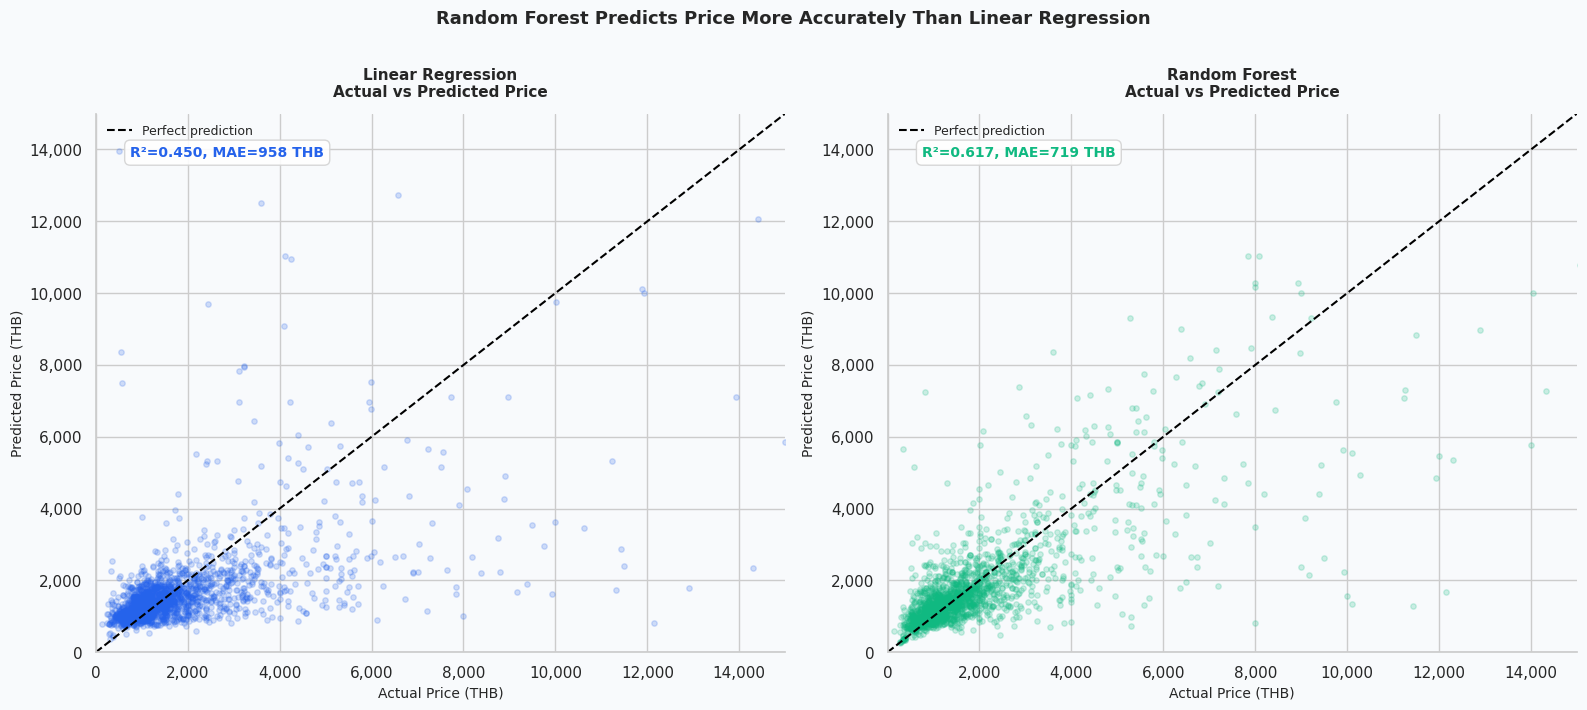

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

models = [
    ('Linear Regression', y_pred_lr, COLORS['primary'],   f"R²=0.450, MAE=958 THB"),
    ('Random Forest',     y_pred_rf, COLORS['accent'],    f"R²=0.617, MAE=719 THB")
]

for ax, (name, y_pred, color, metrics) in zip(axes, models):
    # Convert back to THB for interpretable axis
    actual    = np.expm1(y_test)
    predicted = np.expm1(y_pred)

    # Sample for performance
    idx = np.random.choice(len(actual), size=2000, replace=False)
    ax.scatter(actual.iloc[idx], predicted[idx],
               color=color, alpha=0.2, s=15)

    # Perfect prediction line
    max_val = min(actual.max(), 15000)  # cap at 15k for readability
    ax.plot([0, max_val], [0, max_val],
            color='black', linewidth=1.5, linestyle='--',
            label='Perfect prediction')

    # Metrics annotation
    ax.text(0.05, 0.92, metrics,
            transform=ax.transAxes,
            fontsize=10, fontweight='bold',
            color=color,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor='lightgray', alpha=0.9))

    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_title(f'{name}\nActual vs Predicted Price',
                 fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('Actual Price (THB)', fontsize=10)
    ax.set_ylabel('Predicted Price (THB)', fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(frameon=False, fontsize=9)

plt.suptitle('Random Forest Predicts Price More Accurately Than Linear Regression',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

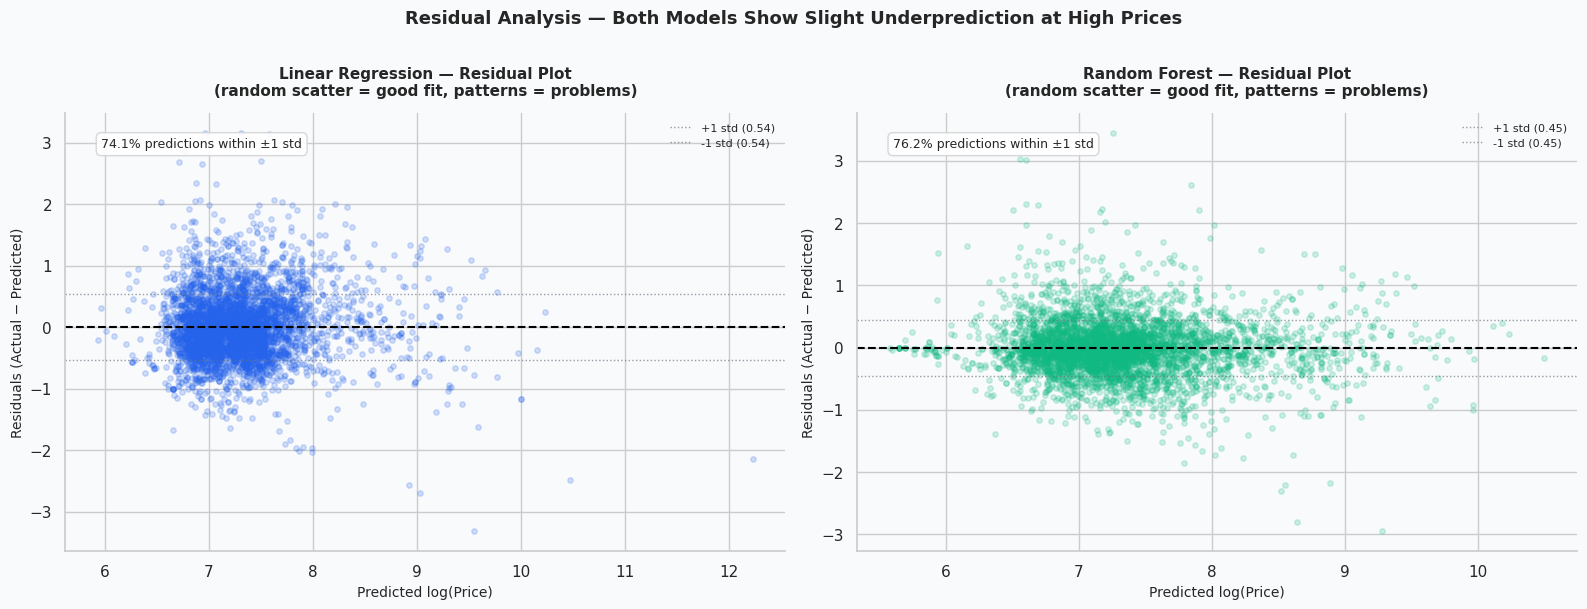


Linear Regression residuals:
  Mean:  0.0012  (near 0 = unbiased)
  Std:   0.5368
  Skew:  0.5442  (near 0 = symmetric errors)

Random Forest residuals:
  Mean:  -0.0109  (near 0 = unbiased)
  Std:   0.4479
  Skew:  0.4822  (near 0 = symmetric errors)


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = [
    ('Linear Regression', y_pred_lr, COLORS['primary']),
    ('Random Forest',     y_pred_rf, COLORS['accent'])
]

for ax, (name, y_pred, color) in zip(axes, models):
    residuals = y_test - y_pred  # in log scale

    ax.scatter(y_pred, residuals,
               color=color, alpha=0.2, s=15)

    # Zero line — perfect prediction
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Confidence band — ±1 std
    std = residuals.std()
    ax.axhline( std, color=COLORS['neutral'], linewidth=1, linestyle=':', alpha=0.7, label=f'+1 std ({std:.2f})')
    ax.axhline(-std, color=COLORS['neutral'], linewidth=1, linestyle=':', alpha=0.7, label=f'-1 std ({std:.2f})')

    # Annotate % within ±1 std
    within_1std = ((residuals >= -std) & (residuals <= std)).mean() * 100
    ax.text(0.05, 0.92, f'{within_1std:.1f}% predictions within ±1 std',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor='lightgray', alpha=0.9))

    ax.set_title(f'{name} — Residual Plot\n(random scatter = good fit, patterns = problems)',
                 fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted log(Price)', fontsize=10)
    ax.set_ylabel('Residuals (Actual − Predicted)', fontsize=10)
    ax.legend(frameon=False, fontsize=8)

plt.suptitle('Residual Analysis — Both Models Show Slight Underprediction at High Prices',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print residual stats
for name, y_pred in [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    residuals = y_test - y_pred
    print(f"\n{name} residuals:")
    print(f"  Mean:  {residuals.mean():.4f}  (near 0 = unbiased)")
    print(f"  Std:   {residuals.std():.4f}")
    print(f"  Skew:  {residuals.skew():.4f}  (near 0 = symmetric errors)")

### Finding — Price Prediction Models

| Metric | Linear Regression | Random Forest | Improvement |
|--------|------------------|---------------|-------------|
| MAE    | 958 THB          | 719 THB       | 24.9% better |
| RMSE   | 3,536 THB        | 1,925 THB     | 45.5% better |
| R²     | 0.450            | 0.617         | 37.1% better |

Random Forest outperforms Linear Regression across all metrics, capturing 
non-linear relationships between features and price that Linear Regression 
cannot model. An R² of 0.617 means the model explains 62% of price variance 
where unobserved factors (interior 
quality, photos, exact view) account for the remaining 38%.

Both models are unbiased (mean residual ≈ 0) but show slight underprediction 
at high prices. The RMSE gap (3,536 vs 1,925 THB) confirms Linear Regression 
makes significantly larger errors on premium listings.